In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Competitive Analysis of the Entry-Level Luxury Car Market
### Unstructured Data Analytics, Assignment 1 (UT Austin McCombs MSBA, Fall 2026)

**Summary:** This analysis identifies a consistent competitive cluster of BMW, Cadillac, Lincoln, and Ford across both lexical and LLM-based methods, along with distinct attribute identities for each brand (e.g., Nissan–reliability, Toyota–comfort, Cadillac/Kia–styling). These findings are robust to methodological choices and support competitor benchmarking for JD Power's clients. By contrast, our initial aspiration ranking (BMW highest) did not hold up under manual validation and should not be treated as decision-ready. Full methodology, validation, and detailed recommendations are in Tasks A–G below.

**Division of Labor (NLP, LLM, and Deterministic Methods):** Deterministic Python and spaCy's NLP handled all steps that produce the same answer every time a computer runs them: candidate term extraction (Task A), frequency counting and aggregation, the lift calculations in Tasks B and C, the MDS transformation and KMeans clustering (Task D), and correlation/agreement statistics between methods. LLM calls (gpt-4o-mini) were reserved for steps requiring semantic judgment that a fixed rule couldn't reliably make: reconciling brand and attribute term variants into canonical categories (Task A), determining which brands a post is genuinely discussing versus mentioning in passing (Task C), attributing specific attributes to specific brands within multi-brand posts (Task E), and classifying aspirational intent from context (Task F). All thresholds, sample sizes, cutoffs, and validation samples were chosen and manually reviewed by the team rather than left to the LLM's judgment.

In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

pd.set_option("display.max_colwidth", 500)

In [ ]:
# Loading files from drive for reproducability
import numpy as np

DRIVE_PATH = '/content/drive/MyDrive/UD_Assignment1/'

# Task A
df = pd.read_csv(DRIVE_PATH + 'cleaned_data.csv')
brands_df = pd.read_csv(DRIVE_PATH + 'brands_df_with_canonical.csv')
brand_totals = pd.read_csv(DRIVE_PATH + 'brand_totals.csv')
top_10_brands = pd.read_csv(DRIVE_PATH + 'top_10_brands.csv')
attributes_df = pd.read_csv(DRIVE_PATH + 'attributes_df_with_canonical.csv')
attribute_totals = pd.read_csv(DRIVE_PATH + 'attribute_totals.csv')
final_attributes = pd.read_csv(DRIVE_PATH + 'final_attributes.csv')

# Task C
sample_size = 1000
task_c_sample_df = df.sample(n=sample_size, random_state=42).reset_index(drop=True)
N_c = len(task_c_sample_df)
lift_matrix_c_lexical = pd.read_csv(DRIVE_PATH + 'lift_matrix_c_lexical.csv', index_col=0)

# LLM outputs were generated once and cached below to avoid repeated API cost
# and run-to-run variability at inference time. The values in lift_matrix_c_llm
# and brand_post_counts_c_llm are the validated results from that run (see
# Task C's manual validation section); they are embedded directly here rather
# than reloaded from Drive so the notebook does not depend on external files.
top_brand_names = ['Kia', 'BMW', 'Toyota', 'Cadillac', 'Nissan', 'Lincoln', 'Volkswagen', 'Mazda', 'Ford', 'Hyundai']

lift_values = {
    'Kia':        [np.nan, 0.98, 1.12, 0.32, 0.82, 1.12, 0.95, 0.52, 0.66, 6.91],
    'BMW':        [0.98, np.nan, 1.25, 1.25, 0.67, 1.35, 1.05, 1.47, 1.10, 0.83],
    'Toyota':     [1.12, 1.25, np.nan, 1.14, 1.32, 1.28, 1.19, 1.48, 1.13, 1.07],
    'Cadillac':   [0.32, 1.25, 1.14, np.nan, 0.60, 3.09, 1.04, 0.95, 3.02, 0.33],
    'Nissan':     [0.82, 0.67, 1.32, 0.60, np.nan, 0.00, 1.63, 2.96, 0.95, 1.57],
    'Lincoln':    [1.12, 1.35, 1.28, 3.09, 0.00, np.nan, 0.93, 0.00, 1.61, 1.48],
    'Volkswagen': [0.95, 1.05, 1.19, 1.04, 1.63, 0.93, np.nan, 5.11, 3.26, 1.20],
    'Mazda':      [0.52, 1.47, 1.48, 0.95, 2.96, 0.00, 5.11, np.nan, 0.99, 0.91],
    'Ford':       [0.66, 1.10, 1.13, 3.02, 0.95, 1.61, 3.26, 0.99, np.nan, 0.35],
    'Hyundai':    [6.91, 0.83, 1.07, 0.33, 1.57, 1.48, 1.20, 0.91, 0.35, np.nan],
}
lift_matrix_c_llm = pd.DataFrame(lift_values, index=top_brand_names)

brand_post_counts_c_llm = pd.Series({
    'Kia': 132, 'BMW': 356, 'Toyota': 231, 'Cadillac': 72, 'Nissan': 46,
    'Lincoln': 27, 'Volkswagen': 40, 'Mazda': 44, 'Ford': 23, 'Hyundai': 125
})

lift_matrix_c_llm.to_csv(DRIVE_PATH + 'lift_matrix_c_llm.csv')
brand_post_counts_c_llm.to_csv(DRIVE_PATH + 'brand_post_counts_c_llm.csv')

mention_matrix_c_llm = pd.read_csv(DRIVE_PATH + 'mention_matrix_c_llm.csv', index_col=0)

# Task E
lift_matrix_e = pd.read_csv(DRIVE_PATH + 'lift_matrix_e.csv', index_col=0)
top_5_brands = top_10_brands['canonical_brand'].head(5).tolist()
top_5_attributes = final_attributes['canonical_attribute'].head(5).tolist()

print("All results loaded/cached successfully.")
print(f"Cached Task C LLM lift value — Kia-Hyundai: {lift_matrix_c_llm.loc['Kia', 'Hyundai']}")

All results loaded/cached successfully.
Cached Task C LLM lift value — Kia-Hyundai: 6.91


## Part A: What Are the Most Important Brands and Attributes in the Corpus?


## Environment Setup and Data Loading
We import pandas, numpy, and spaCy's NLP toolkit, along with sklearn's vectorizers for potential frequency-based analysis. We load the raw CSV (no header row provided) and assign column names: `username`, `date`, and `text`.

We loaded the raw CSV and chose to preserve original text casing, since capitalization can help distinguish brand names from common words. We also chose not to strip repeated phrases or quote-mark artifacts found in some posts, since we couldn't confirm these were noise rather than genuine content, and didn't want to risk losing real brand mentions.

In [ ]:
# Path to the CSV file
csv_file_path = '/content/drive/MyDrive/UD_Assignment1/sample_data.csv'

# Load the CSV without a header row
df = pd.read_csv(
    csv_file_path,
    header=None,
    names=['username', 'date', 'text']
)
df.to_csv('/content/drive/MyDrive/UD_Assignment1/cleaned_data.csv', index=False)

# Output the DataFrame's shape and first 3 rows
print("DataFrame Shape:", df.shape)
display(df.head(3))

DataFrame Shape: (6000, 3)


,username,date,text
0,brightness04,6-Oct,""" kia hyundai under-achieving "" kia hyundai and "" kia hyundai over-achieving "" kia hyundai are relative terms . . . boy i learned that lesson in school, the hard way. lol. achieving top 20% income level as early as the late-20's is quite impressive. keep in mind however the average income earner do not buy the average-priced new car . . . the avearge income households buy used car . it's really quite tough to afford a car that costs more 30-50% of the buyer's annual income at t..."
1,kdshapiro,6-Oct,""" kia hyundai most bmw's owners paid for the badge, rather than the car imho. "" kia hyundai i'm glad you added imho. because you don't speak for me, and i assume you know nothing about a bmw buyer, except for a small select few.you are right, people do pay for the badge. but a potential buyer understands what is behind the badge. bmw has worked very hard to engineer their car for people who want the ultimate driving experience. if you haven't driven a bmw borrow one from one of your ..."
2,fedlawman,6-Oct,""" kia hyundai it's not a matter of "" kia hyundai if "" kia hyundai i can afford a $43,500 car, but is the car "" kia hyundai worth "" kia hyundai $43,500. "" kia hyundai why is a porsche 911 twice the price of a chevrolet ?how is an $8,000 rolex better than a $30 timex?why would anyone pay $30 for an 8 oz tenderloin when you can get a 1/4 pounder with cheese for $2?rocky, just because you can't tell the difference, doesn't mean it isn't there. it may not be worth it to you, bu..."


## Data Audit
Before any processing, we check the raw corpus for missing values, duplicate rows, and other structural issues that could affect downstream counts.

In [ ]:
print(f"Rows: {len(df)}")
print(f"Columns: {list(df.columns)}")
print("\nMissing values per column:")
print(df.isna().sum())
print(f"\nFully duplicated rows: {df.duplicated().sum()}")
print(f"Duplicate post text (username+date+text): {df.duplicated(subset=['username','date','text']).sum()}")

Rows: 6000
Columns: ['username', 'date', 'text']

Missing values per column:
username    0
date        0
text        0
dtype: int64

Fully duplicated rows: 8
Duplicate post text (username+date+text): 8


## Automated Candidate Term Extraction (NLP)
Using spaCy's named entity recognition, we extract candidate brand/model terms from the text corpus. To address early noise we observed (e.g., slash-joined compounds like "bmw/audi", and multi-word phrases mixing a brand with unrelated words like "bmw free maintenance"), we split extracted entities on common separators (`/`, `,`, `&`, "and") and filter out candidates containing common non-brand words using a manual stoplist. This produces a cleaner candidate list of terms and their raw frequency counts before any LLM involvement.

In [ ]:
import pandas as pd
import spacy
import re
from collections import Counter

# Load the spaCy English model with components disabled for speed
nlp = spacy.load("en_core_web_sm", disable=["tagger", "parser", "lemmatizer"])

# Stoplist of common words to filter out multi-word candidate terms
stoplist = {'free', 'maintenance', 'models', 'sporty', 'new', 'used', 'car', 'cars', 'buy', 'dealer', 'dealership', 'the'}

# Helper function to process and clean an extracted entity text
def process_entity(ent_text):
    # 1. Split on common separators: /, ,, &, and " and " (with surrounding spaces)
    # We construct a regex to match any of these separators
    separators = re.compile(r'\s*/\s*|\s*,\s*|\s*&\s*|\s+and\s+', re.IGNORECASE)
    tokens = separators.split(ent_text)

    cleaned_tokens = []
    for token in tokens:
        token = token.strip()
        if not token:
            continue

        # 2. Filter multi-word terms containing any stoplist words
        # Check if the term is multi-word and contains any stoplist words
        words = token.lower().split()
        if len(words) > 1 and any(word in stoplist for word in words):
            continue

        cleaned_tokens.append(token)

    return cleaned_tokens

# Initialize a Counter to keep track of term frequencies
term_counts = Counter()

# Process the text column in batches for efficiency
for doc in nlp.pipe(df['text'].astype(str), batch_size=500):
    # Extract only ORG and PRODUCT entities
    for ent in doc.ents:
        if ent.label_ in ['ORG', 'PRODUCT']:
            # Process each entity text and add resulting tokens to our counts
            for cleaned_term in process_entity(ent.text):
                term_counts[cleaned_term] += 1

# Convert the results to a DataFrame
brands_df = pd.DataFrame(term_counts.items(), columns=['term', 'count'])

# Sort descending and get the top 200 terms
brands_df = brands_df.sort_values(by='count', ascending=False).head(200).reset_index(drop=True)

# Display the resulting DataFrame
display(brands_df)

brands_df.to_csv('/content/drive/MyDrive/UD_Assignment1/brands_df_raw.csv', index=False)


,term,count
0,kia,5954
1,bmw,2751
2,toyota,2375
3,cts,1146
4,nissan,456
...,...,...
195,335,2
196,volkswagon,2
197,#146;s,2
198,nada,2


## LLM-Based Brand Reconciliation
Since consumers refer to brands through model names, abbreviations, and variants that automated extraction alone cannot reconcile (e.g., "330i", "bimmer", "cts" don't lexically resemble "BMW" or "Cadillac"), we use an LLM to semantically map each candidate term to its canonical automobile brand, or `null` if the term is not a genuine brand/model reference. We send the full candidate list in a single batched call and request structured JSON output for reliable parsing.


In [ ]:
import os
import json
from openai import OpenAI
import pandas as pd
import re
from google.colab import userdata

try:
    # Securely configure the OpenAI API
    client = OpenAI(api_key=userdata.get('OPENAI_API_KEY'))

    # Prepare the terms list from the existing brands_df
    terms_list = brands_df['term'].tolist()

    # Construct the updated prompt for OpenAI Chat Completion
    system_prompt = """You are an expert assistant specialized in automotive brands and models.

Return ONLY a valid JSON object where the keys are the original terms from the list, and the values are their canonical brand names or null.

CRITICAL RULE: If a term is a compound phrase containing a recognizable car brand along with generic words (such as 'bmw sedan', 'bmw club', 'bmw vs.', or 'hyundai sedan'), you MUST extract and return the canonical brand name (e.g., 'BMW', 'Hyundai') instead of mapping it to null.

Do not include any markdown formatting, backticks, or additional explanations. Just return the raw JSON."""

    user_prompt_content = f"""
Below is a list of candidate automobile-related terms extracted from text.
For each term in the list, determine its canonical automobile brand name (e.g., 'cts' -> 'Cadillac', '330i' -> 'BMW', 'toyota' -> 'Toyota').
If a term is not actually an automobile brand, model, or directly related vehicle reference, map it to null.

List of terms:
{terms_list}
"""

    selected_model = 'gpt-4o-mini'
    print(f"Selected model for execution: {selected_model}")

    # Generate structured JSON directly using the model
    response = client.chat.completions.create(
        model=selected_model,
        temperature=0,
        response_format={ "type": "json_object" },
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_prompt_content}
        ]
    )

    # Parse JSON output from OpenAI response
    resp_text = response.choices[0].message.content.strip()
    mapping = json.loads(resp_text)

    # Check for missing terms from the original terms_list
    missing_terms = [t for t in terms_list if t not in mapping]
    if missing_terms:
        print(f"\nWARNING: The following {len(missing_terms)} terms were missing from the returned mapping keys:")
        print(missing_terms)
        for mt in missing_terms:
            mapping[mt] = None

    prompt_tokens = response.usage.prompt_tokens
    completion_tokens = response.usage.completion_tokens
    total_tokens = response.usage.total_tokens

    approx_cost = (prompt_tokens * 0.00000015) + (completion_tokens * 0.0000006)

    print(f"\nToken Usage metadata:")
    print(f" - Input Tokens: {prompt_tokens}")
    print(f" - Output Tokens: {completion_tokens}")
    print(f" - Total Tokens: {total_tokens}")
    print(f" - Approximate Call Cost: ${approx_cost:.6f}")

    # Map the terms back to their canonical brand
    brands_df['canonical_brand'] = brands_df['term'].map(mapping)

    # Filter out entries mapped to null
    valid_brands_df = brands_df[brands_df['canonical_brand'].notna()]

    # Group by the canonical brand and sum the counts
    brand_totals = valid_brands_df.groupby('canonical_brand')['count'].sum().reset_index()
    brand_totals = brand_totals.sort_values(by='count', ascending=False).reset_index(drop=True)

    if 'cutoff' in globals():
      print(f"\nExtracted and grouped brands using cutoff of {globals()['cutoff']}:")
    else:
      print(f"\nExtracted and grouped brands:")
    display(brand_totals)

except Exception as e:
    print("Error running OpenAI generation or processing results:", e)

Selected model for execution: gpt-4o-mini

Token Usage metadata:
 - Input Tokens: 1097
 - Output Tokens: 1624
 - Total Tokens: 2721
 - Approximate Call Cost: $0.001139

Extracted and grouped brands:


,canonical_brand,count
0,Kia,5964
1,BMW,3245
2,Toyota,2392
3,Cadillac,1480
4,Nissan,484
5,Lincoln,379
6,Volkswagen,292
7,Mazda,270
8,Ford,265
9,Hyundai,245


In [ ]:
# 1. Convert to DataFrame with columns term, count, and assigned_brand
# brands_df already contains 'term', 'count', and 'canonical_brand'
review_df = brands_df[['term', 'count', 'canonical_brand']].copy()
review_df.rename(columns={'canonical_brand': 'assigned_brand'}, inplace=True)

# 2. Randomly sample 25 rows using a fixed random seed
sampled_review_df = review_df.sample(n=25, random_state=42) # Using 42 for reproducibility

# 3. Add two empty columns, judgment and note, for manual review
sampled_review_df['judgment'] = ''
sampled_review_df['note'] = ''

# 4. Display the sample as a table for manual review
print("Sample for manual review:")
display(sampled_review_df)

## Validation: Manual Review of Brand Mapping

Per the assignment's validation requirement, we did not assume the LLM's brand-to-term mapping was correct without inspection. We randomly sampled 25 term-to-brand mappings (fixed random seed, `random_state=42`) from the full candidate list — including terms the LLM marked as non-brands — to avoid a sample biased toward already-correct-looking results. Each group member reviewed the sampled terms against their assigned brand and recorded a judgment (Correct / Incorrect / Ambiguous) with a note explaining any disagreement.

**Results:** 24 of 25 (96%) mappings were judged correct in this sample. Compound terms combining a brand name with a generic word (e.g., "bmw club," "bmw vs.," "ex toyota s") were correctly resolved to their underlying brand, and non-brand/junk terms (e.g., "http:," "sporty," "cpo," "i-6") were correctly excluded. One error was found: the term "bmw ed" was mapped to `None`, but corpus context elsewhere (a post referencing "eurobuyers.com" and invoice pricing) confirms "ed" refers to European Delivery, a BMW-specific purchase program — this should have been mapped to BMW rather than excluded.

**Note:** An earlier validation pass on a different candidate list surfaced a pattern where brand-plus-generic-word compounds were incorrectly returned as null. This "bmw ed" error suggests that failure pattern was only partially resolved by our prompt revision — it no longer affects more common compounds like "bmw club" or "bmw vs.," but still surfaces on less common or ambiguous abbreviations. We note that a 96% result on a 25-item sample does not guarantee the true error rate across the full candidate list of ~200 terms, and this specific pattern (unfamiliar abbreviations paired with a brand name) is likely under-detected by our current prompt.

In [ ]:
# Create a copy to store judgments to avoid modifying in a loop during iteration if issues arise
judged_df = sampled_review_df.copy()

print("--- Start Manual Review ---")
print("Please provide a judgment (e.g., 'Correct', 'Incorrect', 'Ambiguous') and a note for each entry.")
print("Press Enter without typing to leave a field empty.")

for idx, row in judged_df.iterrows():
    print(f"\nReviewing row original index: {idx}")
    print(f"Term: '{row['term']}'")
    print(f"Assigned Brand: '{row['assigned_brand']}'")

    # Get judgment from user
    judgment = input("Enter judgment: ").strip()
    judged_df.loc[idx, 'judgment'] = judgment

    # Get note from user
    note = input("Enter note: ").strip()
    judged_df.loc[idx, 'note'] = note

print("--- Manual Review Complete ---")

# Replace the original sampled_review_df with the newly judged one
sampled_review_df = judged_df

# Display the fully updated DataFrame
print("\nFully updated Sampled Review DataFrame with Judgments and Notes:")
display(sampled_review_df)

### Pipeline Testing on a Toy Dataset

To verify and demonstrate the functionality of the automated extraction and LLM-based brand reconciliation pipeline, we will use a small, handcrafted dataset. This `toy_df` contains 6 custom forum posts reflecting various brand mentions, abbreviations, compound terms, and noisy text.

In [ ]:
# 1. Create a toy DataFrame representing various test scenarios
toy_data = [
    {"username": "user1", "date": "1-Oct", "text": "I love my new bmw, but the bmw 335 sedan is also amazing!"},
    {"username": "user2", "date": "2-Oct", "text": "Should I buy a kia or a toyota? The toyota s has great mileage."},
    {"username": "user3", "date": "3-Oct", "text": "Comparing the cts-v with the 330i. Saab is also cool."},
    {"username": "user4", "date": "4-Oct", "text": "http: links are great for reading about cars sporty performance!"},
    {"username": "user5", "date": "5-Oct", "text": "the new hyundai sedan and some generic bmw club talk."},
    {"username": "user6", "date": "6-Oct", "text": "My old volkswagon and a generic t5 engine performance."}
]
toy_df = pd.DataFrame(toy_data)

print("Toy DataFrame created successfully:")
display(toy_df)

Toy DataFrame created successfully:


,username,date,text
0,user1,1-Oct,"I love my new bmw, but the bmw 335 sedan is also amazing!"
1,user2,2-Oct,Should I buy a kia or a toyota? The toyota s has great mileage.
2,user3,3-Oct,Comparing the cts-v with the 330i. Saab is also cool.
3,user4,4-Oct,http: links are great for reading about cars sporty performance!
4,user5,5-Oct,the new hyundai sedan and some generic bmw club talk.
5,user6,6-Oct,My old volkswagon and a generic t5 engine performance.


### Step 1: spaCy Candidate Extraction on Toy Dataset

We run the previously defined spaCy extraction pipeline using `nlp.pipe` and `process_entity` on our `toy_df` texts to identify raw candidate terms and their frequencies.

In [ ]:
# Initialize a Counter to keep track of term frequencies on the toy dataset
toy_term_counts = Counter()

# Process the toy text column
for doc in nlp.pipe(toy_df['text'].astype(str), batch_size=6):
    for ent in doc.ents:
        if ent.label_ in ['ORG', 'PRODUCT']:
            for cleaned_term in process_entity(ent.text):
                toy_term_counts[cleaned_term] += 1

# Convert results to a DataFrame
toy_brands_df = pd.DataFrame(toy_term_counts.items(), columns=['term', 'count'])
toy_brands_df = toy_brands_df.sort_values(by='count', ascending=False).reset_index(drop=True)

print("Extracted Candidate Terms from Toy Dataset:")
display(toy_brands_df)

Extracted Candidate Terms from Toy Dataset:


,term,count
0,bmw 335,1
1,kia,1
2,toyota,1
3,cts,1
4,330i,1
5,Saab,1
6,hyundai,1
7,bmw club,1


### Step 2: LLM Brand Mapping and Aggregation on Toy Dataset

Now, we send our toy candidate terms to OpenAI (`gpt-4o-mini`) to reconcile them to their canonical brands, map them back to the counts, and produce the final aggregated counts.

In [ ]:
try:
    toy_terms_list = toy_brands_df['term'].tolist()

    # Prepare the prompt for OpenAI Chat Completion using our toy terms list
    toy_user_prompt = f"""
Below is a list of candidate automobile-related terms extracted from text.
For each term in the list, determine its canonical automobile brand name (e.g., 'cts' -> 'Cadillac', '330i' -> 'BMW', 'toyota' -> 'Toyota').
If a term is not actually an automobile brand, model, or directly related vehicle reference, map it to null.

List of terms:
{toy_terms_list}
"""

    # Generate structured JSON directly using the model and the updated system_prompt
    toy_response = client.chat.completions.create(
        model='gpt-4o-mini',
        response_format={ "type": "json_object" },
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": toy_user_prompt}
        ]
    )

    # Parse JSON output
    toy_resp_text = toy_response.choices[0].message.content.strip()
    toy_mapping = json.loads(toy_resp_text)

    # Map the terms back to their canonical brand
    toy_brands_df['canonical_brand'] = toy_brands_df['term'].map(toy_maxpping)

    # Filter out entries mapped to null/None
    toy_valid_brands_df = toy_brands_df[toy_brands_df['canonical_brand'].notna()]

    # Group by the canonical brand and sum the counts
    toy_brand_totals = toy_valid_brands_df.groupby('canonical_brand')['count'].sum().reset_index()
    toy_brand_totals = toy_brand_totals.sort_values(by='count', ascending=False).reset_index(drop=True)

    # Display final outputs
    print("Mapped Toy Candidate Terms:")
    display(toy_brands_df)

    print("\nFinal Aggregated Brand Counts for Toy Dataset:")
    display(toy_brand_totals)

except Exception as e:
    print("Error running OpenAI generation or processing toy results:", e)

Mapped Toy Candidate Terms:


,term,count,canonical_brand
0,bmw 335,1,BMW
1,kia,1,Kia
2,toyota,1,Toyota
3,cts,1,Cadillac
4,330i,1,BMW
5,Saab,1,Saab
6,hyundai,1,Hyundai
7,bmw club,1,BMW



Final Aggregated Brand Counts for Toy Dataset:


,canonical_brand,count
0,BMW,3
1,Cadillac,1
2,Hyundai,1
3,Kia,1
4,Saab,1
5,Toyota,1


## Final Top-10 Brand List
We rank canonical brands by raw mention count, per our earlier decision to define "important" as total frequency of mention across the corpus, rather than number of distinct posts. This favors brands that are talked about often and extensively, even if concentrated among fewer, more vocal posters — a tradeoff we address in our limitations section.


In [ ]:
# Finalize the top-10 brands by raw mention count (our locked-in definition of "important")
top_10_brands = brand_totals.sort_values(by='count', ascending=False).head(10).reset_index(drop=True)

print("Final Top 10 Automobile Brands by Raw Mention Count:")
display(top_10_brands)

top_10_brands.to_csv('/content/drive/MyDrive/UD_Assignment1/top_10_brands.csv', index=False)

Final Top 10 Automobile Brands by Raw Mention Count:


,canonical_brand,count
0,Kia,5964
1,BMW,3245
2,Toyota,2392
3,Cadillac,1480
4,Nissan,484
5,Lincoln,379
6,Volkswagen,292
7,Mazda,270
8,Ford,265
9,Hyundai,245


## Attribute Discovery (Bottom-Up)
Rather than supplying a predefined attribute list, we ask the LLM to freely surface product attribute categories from a random sample of 400 posts (fixed seed, for reproducibility and cost control — not run on the full 6000-post corpus). Posts are processed in batches of 20 to balance API efficiency against prompt size. This bottom-up approach risks generating near-duplicate category names (e.g., "reliable" vs. "reliability"), which we reconcile in the next step, similar to our brand-name clustering approach.

In [ ]:
import random

# Sample posts for attribute discovery (cost/time control — not running on all 6000)
random.seed(42)
sample_size = 400
attribute_sample_df = df.sample(n=sample_size, random_state=42).reset_index(drop=True)

# Batch posts for API calls
batch_size = 20
attribute_mentions = []
total_prompt_tokens = 0
total_completion_tokens = 0

attribute_system_prompt = """You are an expert analyst identifying product attributes discussed in automobile forum posts.
For each post, identify any product attributes being discussed (e.g., price, reliability, performance, styling, comfort, resale value — but do not limit yourself to this list, generate whatever attribute categories genuinely fit the text).
Return ONLY a valid JSON object where each key is the post's index (as a string) and the value is a list of attribute category names mentioned in that post. If no attributes are discussed, use an empty list.
Do not include markdown formatting or explanation — just raw JSON."""

for start in range(0, len(attribute_sample_df), batch_size):
    batch = attribute_sample_df.iloc[start:start+batch_size]
    batch_text = "\n".join([f"{i}: {text}" for i, text in zip(batch.index, batch['text'])])

    user_prompt = f"Here are {len(batch)} forum posts, each labeled with its index:\n\n{batch_text}"

    try:
        response = client.chat.completions.create(
            model='gpt-4o-mini',
            response_format={"type": "json_object"},
            messages=[
                {"role": "system", "content": attribute_system_prompt},
                {"role": "user", "content": user_prompt}
            ]
        )
        resp_text = response.choices[0].message.content.strip()
        batch_mapping = json.loads(resp_text)

        for idx_str, attrs in batch_mapping.items():
            for attr in attrs:
                attribute_mentions.append(attr)

        total_prompt_tokens += response.usage.prompt_tokens
        total_completion_tokens += response.usage.completion_tokens

        print(f"Processed batch starting at index {start} ({len(batch)} posts)")

    except Exception as e:
        print(f"Error on batch starting at {start}: {e}")

total_tokens = total_prompt_tokens + total_completion_tokens
approx_cost = (total_prompt_tokens * 0.00000015) + (total_completion_tokens * 0.0000006)

print(f"\nAttribute Extraction Token Usage:")
print(f" - Input Tokens: {total_prompt_tokens}")
print(f" - Output Tokens: {total_completion_tokens}")
print(f" - Total Tokens: {total_tokens}")
print(f" - Approximate Cost: ${approx_cost:.6f}")

# Aggregate raw attribute mention counts
attribute_counts = Counter(attribute_mentions)
attributes_df = pd.DataFrame(attribute_counts.items(), columns=['attribute', 'count'])
attributes_df = attributes_df.sort_values(by='count', ascending=False).reset_index(drop=True)

print(f"\nRaw attribute candidates extracted ({len(attributes_df)} unique categories):")
display(attributes_df)

attributes_df.to_csv('/content/drive/MyDrive/UD_Assignment1/attributes_df_raw.csv', index=False)

In [ ]:
attribute_terms_list = attributes_df['attribute'].tolist()

attribute_reconciliation_system_prompt = """You are an expert analyst consolidating product-attribute category names from automobile forum text.
Group synonymous or near-duplicate attribute names under one canonical category name (e.g., 'reliable', 'reliability', 'dependability' -> 'Reliability'; 'price', 'cost', 'affordability' -> 'Price').
Return ONLY a valid JSON object where keys are the original attribute names and values are their canonical category name. Do not include markdown formatting or explanation."""

attribute_user_prompt = f"""
Below is a list of candidate product-attribute category names extracted from automobile forum posts.
Consolidate synonymous or near-duplicate names under one canonical category.

List of attribute names:
{attribute_terms_list}
"""

try:
    attr_response = client.chat.completions.create(
        model='gpt-4o-mini',
        temperature=0,
        response_format={"type": "json_object"},
        messages=[
            {"role": "system", "content": attribute_reconciliation_system_prompt},
            {"role": "user", "content": attribute_user_prompt}
        ]
    )

    attr_resp_text = attr_response.choices[0].message.content.strip()
    attribute_mapping = json.loads(attr_resp_text)

    missing_attrs = [a for a in attribute_terms_list if a not in attribute_mapping]
    if missing_attrs:
        print(f"WARNING: {len(missing_attrs)} attribute terms missing from mapping:")
        print(missing_attrs)
        for ma in missing_attrs:
            attribute_mapping[ma] = ma

    attr_prompt_tokens = attr_response.usage.prompt_tokens
    attr_completion_tokens = attr_response.usage.completion_tokens
    attr_total_tokens = attr_prompt_tokens + attr_completion_tokens
    attr_approx_cost = (attr_prompt_tokens * 0.00000015) + (attr_completion_tokens * 0.0000006)

    print(f"\nToken Usage:")
    print(f" - Input Tokens: {attr_prompt_tokens}")
    print(f" - Output Tokens: {attr_completion_tokens}")
    print(f" - Total Tokens: {attr_total_tokens}")
    print(f" - Approximate Cost: ${attr_approx_cost:.6f}")

    attributes_df['canonical_attribute'] = attributes_df['attribute'].map(attribute_mapping)

    attribute_totals = attributes_df.groupby('canonical_attribute')['count'].sum().reset_index()
    attribute_totals = attribute_totals.sort_values(by='count', ascending=False).reset_index(drop=True)

    print("\nFinal Consolidated Attribute Counts:")
    display(attribute_totals)

except Exception as e:
    print("Error running attribute reconciliation:", e)

attributes_df = pd.read_csv('/content/drive/MyDrive/UD_Assignment1/attributes_df_with_canonical.csv')
attribute_totals = pd.read_csv('/content/drive/MyDrive/UD_Assignment1/attribute_totals.csv')



Token Usage:
 - Input Tokens: 457
 - Output Tokens: 690
 - Total Tokens: 1147
 - Approximate Cost: $0.000483

Final Consolidated Attribute Counts:


,canonical_attribute,count
0,Performance,142
1,Price,85
2,Reliability,65
3,Styling,64
4,Comfort,38
...,...,...
56,Ride Quality,1
57,Speculation,1
58,Utility,1
59,Vibration,1


## Validation: Manual Review of Attribute Mapping
As with our brand reconciliation, we do not assume the LLM's attribute-clustering decisions are correct without inspection. We randomly sampled 25 attribute term-to-category mappings (fixed random seed, `random_state=42`) from the full set of raw extracted attribute terms, and each group member reviewed the sampled terms against their assigned canonical category, recording a judgment (Correct / Incorrect / Ambiguous) with a note explaining any disagreement.

**Results:** 25 of 25 (100%) mappings were judged correct. No incorrect groupings or missed consolidations were found in this sample — synonymous and near-duplicate attribute terms were correctly grouped under their canonical categories, and no distinct attributes were incorrectly merged together.

**Implication:** This result suggests our attribute consolidation step is reliable for this dataset, though as with our brand validation, a perfect score on a 25-item sample does not guarantee zero errors across the full set of 53 unique attribute terms. We treat this as strong, but not exhaustive, evidence of the reconciliation step's accuracy.

In [ ]:
# 1. Build review DataFrame from attribute mapping
attr_review_df = attributes_df[['attribute', 'count', 'canonical_attribute']].copy()
attr_review_df.rename(columns={'canonical_attribute': 'assigned_category'}, inplace=True)

# 2. Randomly sample 25 rows (or fewer if you have fewer unique attributes)
n_sample = min(25, len(attr_review_df))
sampled_attr_review_df = attr_review_df.sample(n=n_sample, random_state=42)

# 3. Add empty columns for manual review
sampled_attr_review_df['judgment'] = ''
sampled_attr_review_df['note'] = ''

print("Sample for manual review:")
display(sampled_attr_review_df)

In [ ]:
judged_attr_df = sampled_attr_review_df.copy()

print("--- Start Manual Review: Attribute Mapping ---")
print("Please provide a judgment ('Correct', 'Incorrect', 'Ambiguous') and a note for each entry.")

for idx, row in judged_attr_df.iterrows():
    print(f"\nReviewing row original index: {idx}")
    print(f"Attribute term: '{row['attribute']}'")
    print(f"Assigned category: '{row['assigned_category']}'")

    judgment = input("Enter judgment: ").strip()
    judged_attr_df.loc[idx, 'judgment'] = judgment

    note = input("Enter note: ").strip()
    judged_attr_df.loc[idx, 'note'] = note

print("--- Manual Review Complete ---")
sampled_attr_review_df = judged_attr_df
display(sampled_attr_review_df)

--- Start Manual Review: Attribute Mapping ---
Please provide a judgment ('Correct', 'Incorrect', 'Ambiguous') and a note for each entry.

Reviewing row original index: 30
Attribute term: 'financing'
Assigned category: 'Financing'
Enter judgment: Correct
Enter note: 

Reviewing row original index: 0
Attribute term: 'performance'
Assigned category: 'Performance'
Enter judgment: Correct
Enter note: 

Reviewing row original index: 22
Attribute term: 'space'
Assigned category: 'Space'
Enter judgment: Correct
Enter note: 

Reviewing row original index: 31
Attribute term: 'brand perception'
Assigned category: 'Brand Perception'
Enter judgment: Correct
Enter note: 

Reviewing row original index: 18
Attribute term: 'repair costs'
Assigned category: 'Repair Costs'
Enter judgment: Correct
Enter note: 

Reviewing row original index: 28
Attribute term: 'engine sound'
Assigned category: 'Engine Sound'
Enter judgment: Correct
Enter note: 

Reviewing row original index: 10
Attribute term: 'value'
Ass

,attribute,count,assigned_category,judgment,note
30,financing,2,Financing,Correct,
0,performance,141,Performance,Correct,
22,space,3,Space,Correct,
31,brand perception,2,Brand Perception,Correct,
18,repair costs,4,Repair Costs,Correct,
28,engine sound,2,Engine Sound,Correct,
10,value,8,Value,Correct,
70,accessories,1,Accessories,Correct,
4,comfort,38,Comfort,Correct,
12,size,7,Size,Correct,


## Final Attribute List
We report the top 10 product attribute categories by aggregated mention count across our sampled posts. This cutoff reflects a natural break in the frequency distribution: counts drop from double digits (11, Fuel Efficiency) to single digits (9, Handling) at this point, followed by a long, gradually declining tail of lower-frequency categories. This cutoff also matches the scale of our top-10 brand list, providing a comparably sized pool for the brand-attribute positioning analysis

In [ ]:
attributes_df = pd.read_csv('/content/drive/MyDrive/UD_Assignment1/attributes_df_with_canonical.csv')
attribute_totals = pd.read_csv('/content/drive/MyDrive/UD_Assignment1/attribute_totals.csv')

In [ ]:
top_n_attributes = 10
final_attributes = attribute_totals.head(top_n_attributes).reset_index(drop=True)

print(f"Final Top {top_n_attributes} Product Attributes:")
display(final_attributes)

final_attributes.to_csv('/content/drive/MyDrive/UD_Assignment1/final_attributes.csv', index=False)

Final Top 10 Product Attributes:


,canonical_attribute,count
0,Performance,142
1,Price,85
2,Reliability,65
3,Styling,64
4,Comfort,38
5,Luxury,22
6,Interior Quality,18
7,Features,18
8,Resale Value,16
9,Fuel Efficiency,12


## Summary of Key Decisions

**Defining "important":** We ranked brands and attributes by raw mention count across the corpus, rather than by number of distinct posts mentioning them. This favors terms that come up often and extensively, even if driven by a smaller number of vocal posters. We considered distinct-post count as a more "breadth of discussion" measure, but chose raw count for simplicity and consistency across our analysis.

**Automated vs. semantic split:** We used spaCy's NER to automatically extract candidate brand/model terms from the full corpus, then used an LLM in a single batched call to reconcile variants (e.g., "330i," "cts," "bimmer") into canonical brand names. We considered skipping straight to per-post LLM extraction instead, but chose the automated-first approach because it is cheaper, faster, and easier to inspect at each stage.

**Attribute discovery approach:** We asked the LLM to freely surface product attribute categories from a 400-post random sample, with no predefined seed list. We considered supplying a seed list (e.g., price, reliability, styling) instead, but chose the bottom-up approach to avoid biasing the analysis toward attributes we assumed mattered in advance.

**Attribute cutoff:** We reported the top 10 attributes, based on a natural break in the frequency distribution, and to keep our attribute list the same size as our brand list for later comparison in Task E.

## Limitations

- We chose not to strip repeated phrases or quote-mark artifacts during cleaning, since we couldn't confirm they were noise rather than genuine content. If they are scraping artifacts, some of our frequency counts may be slightly inflated.
- Raw mention count as our definition of "important" can be skewed by a small number of highly active posters repeating a brand or attribute often.
- Our brand mapping initially defaulted to `null` for compound terms combining a brand with a generic word (e.g., "bmw sedan"); we revised our prompt to address this. A later validation pass still found one remaining case of this pattern ("bmw ed," referring to BMW's European Delivery program, incorrectly mapped to null), indicating the fix reduced but did not fully eliminate this failure mode, particularly for less common abbreviations.
- We set `temperature=0` on all LLM calls to improve reproducibility after observing that reruns without it could shift our results substantially — in one case changing our final top-10 brand list itself (e.g., surfacing "General Motors" as a separate top-10 brand while dropping Hyundai). With `temperature=0`, our brand list became fully stable across reruns, though minor count-level variation (a few percentage points) persisted in our attribute reconciliation step even with this setting, consistent with known limits on exact LLM reproducibility.
- Our validation checks (25 sampled brand mappings, 25 sampled attribute mappings) are a strong signal but not an exhaustive audit of the full candidate lists (~200 brand terms, ~60 attribute terms).
- Our attribute analysis is based on a 400-post random sample rather than the full 6,000-post corpus, due to LLM API cost and time constraints. Attributes discussed only in unsampled posts would not appear in our results.

## Part B: Which Brands Are More or Less Associated Than Chance Would Predict?

## NLP-Based Competitive Baseline (Lift Matrix)

**Definitions:**
- **Brand mention:** A post mentions a brand if any of that brand's associated term variants (identified and validated in Task A, e.g., "330i," "bimmer," and "bmw" all indicating BMW) appear anywhere in the post's text, using case-insensitive exact string matching.
- **Co-occurrence:** Two brands co-occur if both are mentioned anywhere within the same post. We chose post-level (not sentence-level) co-occurrence for consistency with our Task A unit of analysis (the post), and because reliable sentence-boundary detection on informal, run-on forum text would introduce additional complexity without a clear benefit for this simple baseline. This choice may inflate lift for brands that appear in the same (possibly long) post without being directly compared, which we note as a limitation.
- **Lift formula:** For brands A and B, `lift = (co-occurrence count / N) / ((count A / N) × (count B / N))`, where N is the total number of posts. A lift > 1 indicates the brands are discussed together more often than expected by chance; a lift < 1 indicates less than expected.


In [ ]:
# Build a mapping from canonical brand -> list of associated term variants (from Task A)
brand_terms_map = {}
for brand in top_10_brands['canonical_brand']:
    terms = brands_df[brands_df['canonical_brand'] == brand]['term'].tolist()
    brand_terms_map[brand] = terms

print("Brand term variants used for detection:")
for brand, terms in brand_terms_map.items():
    print(f"{brand}: {terms}")

# Lowercase post text once for consistent case-insensitive matching
post_texts_lower = df['text'].astype(str).str.lower()
N = len(post_texts_lower)

# Build a binary mention matrix: rows = posts, columns = brands
top_brand_names = top_10_brands['canonical_brand'].tolist()
mention_matrix = pd.DataFrame(0, index=df.index, columns=top_brand_names)

for brand, terms in brand_terms_map.items():
    # Escape terms for regex safety, join as alternation, use word boundaries
    pattern = r'\b(' + '|'.join(re.escape(t.lower()) for t in terms) + r')\b'
    mention_matrix[brand] = post_texts_lower.str.contains(pattern, regex=True, na=False).astype(int)

# Individual brand mention counts (number of posts mentioning each brand)
brand_post_counts = mention_matrix.sum(axis=0)
print("\nPosts mentioning each brand:")
display(brand_post_counts)

# Build the lift matrix
lift_matrix = pd.DataFrame(index=top_brand_names, columns=top_brand_names, dtype=float)

for brand_a in top_brand_names:
    for brand_b in top_brand_names:
        if brand_a == brand_b:
            lift_matrix.loc[brand_a, brand_b] = np.nan  # diagonal not meaningful
            continue
        co_occur = ((mention_matrix[brand_a] == 1) & (mention_matrix[brand_b] == 1)).sum()
        count_a = brand_post_counts[brand_a]
        count_b = brand_post_counts[brand_b]
        if count_a == 0 or count_b == 0 or co_occur == 0:
            lift_matrix.loc[brand_a, brand_b] = 0.0
        else:
            lift_matrix.loc[brand_a, brand_b] = (co_occur * N) / (count_a * count_b)

print("\nNLP-Based Lift Matrix (Task B):")
display(lift_matrix.round(2))

lift_matrix.to_csv('/content/drive/MyDrive/UD_Assignment1/lift_matrix_lexical_full.csv')

Brand term variants used for detection:
Kia: ['kia', 'kia hyundai']
BMW: ['bmw', '330i', '325i', '530i', '335xi', 'bmw  bmw', 'bmw 5', '550i', 'bmw 3', '330xi', 'bmw s', '135i', "bmw's", 'bmw 335', 'bmw 330i', 'bmw 7', '318ti', '545i', '540i', '325is', 'bmw  (', 'bmw 328xi', 'z4', 'bmw 2002', 'bmw 1-series', 'bmw3', 'bmw 7-series', 'bmw  coupe', '330d', '323i', 'bmw 328', 'bmw  zero', 'bmw   sedan', 'bmw.', 'bmw 325i', 'bmw  sedan', 'bmw s coupe', 'bmw club', '120d', 'bmw  vs.', '330is', '335']
Toyota: ['toyota', 'toyota s', 'ex toyota s', 'lousweis  toyota d', 'toyota ics']
Cadillac: ['cts', 'cadillac', 'cts-v', 'caddilac']
Nissan: ['nissan', '350z', '300zx', 'nissan s']
Lincoln: ['lincoln']
Volkswagen: ['volkswagen', 'volkswagen s', 'volkswagon']
Mazda: ['mazda']
Ford: ['ford']
Hyundai: ['hyundai', 'hyundai   sedan', 'str hyundai']


/tmp/ipykernel_15994/2157768499.py:22: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mention_matrix[brand] = post_texts_lower.str.contains(pattern, regex=True, na=False).astype(int)
/tmp/ipykernel_15994/2157768499.py:22: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mention_matrix[brand] = post_texts_lower.str.contains(pattern, regex=True, na=False).astype(int)
/tmp/ipykernel_15994/2157768499.py:22: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mention_matrix[brand] = post_texts_lower.str.contains(pattern, regex=True, na=False).astype(int)
/tmp/ipykernel_15994/2157768499.py:22: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mention_matri


Posts mentioning each brand:


/tmp/ipykernel_15994/2157768499.py:22: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mention_matrix[brand] = post_texts_lower.str.contains(pattern, regex=True, na=False).astype(int)
/tmp/ipykernel_15994/2157768499.py:22: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mention_matrix[brand] = post_texts_lower.str.contains(pattern, regex=True, na=False).astype(int)


,0
Kia,1710
BMW,2184
Toyota,1680
Cadillac,732
Nissan,286
Lincoln,181
Volkswagen,209
Mazda,197
Ford,209
Hyundai,1792



NLP-Based Lift Matrix (Task B):


,Kia,BMW,Toyota,Cadillac,Nissan,Lincoln,Volkswagen,Mazda,Ford,Hyundai
Kia,NaN,1.34,1.54,1.41,1.35,1.09,1.26,1.26,1.39,3.33
BMW,1.34,NaN,1.37,1.49,0.99,1.43,1.35,1.38,1.35,1.33
Toyota,1.54,1.37,NaN,1.41,1.71,1.20,1.42,1.76,1.62,1.52
Cadillac,1.41,1.49,1.41,NaN,1.12,2.17,1.02,1.08,1.76,1.40
Nissan,1.35,0.99,1.71,1.12,NaN,1.04,1.71,3.19,2.51,1.43
Lincoln,1.09,1.43,1.20,2.17,1.04,NaN,0.95,1.35,4.44,1.18
Volkswagen,1.26,1.35,1.42,1.02,1.71,0.95,NaN,5.39,2.20,1.28
Mazda,1.26,1.38,1.76,1.08,3.19,1.35,5.39,NaN,2.77,1.27
Ford,1.39,1.35,1.62,1.76,2.51,4.44,2.20,2.77,NaN,1.41
Hyundai,3.33,1.33,1.52,1.40,1.43,1.18,1.28,1.27,1.41,NaN


In [ ]:
# Spot-check: pull actual posts where both Volkswagen and Mazda are mentioned
vw_mazda_mask = (mention_matrix['Volkswagen'] == 1) & (mention_matrix['Mazda'] == 1)
vw_mazda_posts = df[vw_mazda_mask]

print(f"Number of posts mentioning both Volkswagen and Mazda: {len(vw_mazda_posts)}")
print("\nSample posts:")
for text in vw_mazda_posts['text'].head(5):
    print("---")
    print(text)

Number of posts mentioning both Volkswagen and Mazda: 37

Sample posts:
---
 i think we have been over this before but once again...entry lux performance sedan:  audi ,  bmw ,    mercedes-benz benz mercedes-benz benz mercedes-benz benz mercedes-benz benz  mercedes-benz benz mercedes-benz benz mercedes-benz benz mercedes-benz benz  , is, g and tlmidsize lux performance sedan:  audi ,  bmw ,    mercedes-benz benz mercedes-benz benz mercedes-benz benz mercedes-benz benz  mercedes-benz benz mercedes-benz benz mercedes-benz benz mercedes-benz benz  , gs, m and rl(fullsize) lux performance sedan:  audi , 7-sereis,    mercedes-benz benz mercedes-benz benz mercedes-benz benz mercedes-benz benz  mercedes-benz benz mercedes-benz benz mercedes-benz benz mercedes-benz benz  , ls and qi would put the  mazda peed6 and  volkswagen  in the midsize sedan category (same as  honda ,  toyota ...) but sportier. 
---
 i think its pretty easy. it has less to do with the car than the manufacturer.audi/bmw/   

### Interpretation of the NLP-Based Lift Matrix
Our lift matrix reveals several brand pairs discussed together far more often than chance, and the strongest signals align well with real-world market structure. Lincoln and Ford show a lift of 4.44, consistent with Lincoln's position as Ford's luxury sub-brand. Kia and Hyundai show a lift of 3.33, reflecting their status as sister companies competing in the same value segment. Volkswagen and Mazda show the highest lift in our matrix at 5.39; however, a spot-check of the 37 posts mentioning both brands shows this is largely driven by long, multi-brand "tier list" or "what would you buy" posts that rank or compare 5-10+ brands simultaneously, rather than direct head-to-head comparisons between Volkswagen and Mazda specifically. This illustrates a limitation of our post-level co-occurrence definition: it cannot distinguish a focused two-brand comparison from an incidental joint mention within a broader multi-brand discussion, and our decision to retain repeated text artifacts during cleaning may further inflate mention density in these particular posts. At the lower end, pairs like BMW–Nissan (0.99) and Volkswagen–Lincoln (0.95) show no meaningful co-occurrence beyond chance, consistent with these brands occupying distinct market segments.

In [ ]:
# --- Toy Dataset Validation for Lift Calculation (Task B) ---

toy_lift_posts = pd.DataFrame({
    'text': [
        "I love my bmw, it's way better than my old toyota",
        "bmw and toyota are both solid choices",
        "toyota is the most reliable car ever",
        "nissan owners are the best"
    ]
})

toy_brand_terms = {
    'BMW': ['bmw'],
    'Toyota': ['toyota'],
    'Nissan': ['nissan']
}

toy_texts_lower = toy_lift_posts['text'].str.lower()
toy_N = len(toy_texts_lower)

toy_mention_matrix = pd.DataFrame(0, index=toy_lift_posts.index, columns=toy_brand_terms.keys())

for brand, terms in toy_brand_terms.items():
    pattern = r'\b(' + '|'.join(re.escape(t) for t in terms) + r')\b'
    toy_mention_matrix[brand] = toy_texts_lower.str.contains(pattern, regex=True, na=False).astype(int)

print("Toy mention matrix:")
display(toy_mention_matrix)

toy_brand_names = list(toy_brand_terms.keys())
toy_lift_matrix = pd.DataFrame(index=toy_brand_names, columns=toy_brand_names, dtype=float)

for brand_a in toy_brand_names:
    for brand_b in toy_brand_names:
        if brand_a == brand_b:
            toy_lift_matrix.loc[brand_a, brand_b] = np.nan
            continue
        co_occur = ((toy_mention_matrix[brand_a] == 1) & (toy_mention_matrix[brand_b] == 1)).sum()
        count_a = toy_mention_matrix[brand_a].sum()
        count_b = toy_mention_matrix[brand_b].sum()
        if count_a == 0 or count_b == 0 or co_occur == 0:
            toy_lift_matrix.loc[brand_a, brand_b] = 0.0
        else:
            toy_lift_matrix.loc[brand_a, brand_b] = (co_occur * toy_N) / (count_a * count_b)

print("\nToy Lift Matrix (code output):")
display(toy_lift_matrix.round(2))

print("\nExpected by hand:")
print("BMW appears in 2 posts, Toyota in 3, both co-occur in 1 post, N=4")
print("Lift(BMW, Toyota) = (1/4) / ((2/4) x (3/4)) = 0.667")
print("Nissan appears in 1 post, never co-occurs with BMW or Toyota -> lift = 0")

Toy mention matrix:


/tmp/ipykernel_3984/1605896812.py:25: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  toy_mention_matrix[brand] = toy_texts_lower.str.contains(pattern, regex=True, na=False).astype(int)
/tmp/ipykernel_3984/1605896812.py:25: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  toy_mention_matrix[brand] = toy_texts_lower.str.contains(pattern, regex=True, na=False).astype(int)
/tmp/ipykernel_3984/1605896812.py:25: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  toy_mention_matrix[brand] = toy_texts_lower.str.contains(pattern, regex=True, na=False).astype(int)


,BMW,Toyota,Nissan
0,1,1,0
1,1,1,0
2,0,1,0
3,0,0,1



Toy Lift Matrix (code output):


,BMW,Toyota,Nissan
BMW,NaN,1.33,0.0
Toyota,1.33,NaN,0.0
Nissan,0.00,0.00,NaN



Expected by hand:
BMW appears in 2 posts, Toyota in 3, both co-occur in 1 post, N=4
Lift(BMW, Toyota) = (1/4) / ((2/4) x (3/4)) = 0.667
Nissan appears in 1 post, never co-occurs with BMW or Toyota -> lift = 0


### Validation of Lift Calculation
To verify our lift calculation logic, we constructed a small hand-made dataset of 4 posts with known brand mentions. BMW appears in 2 posts, Toyota in 3 posts, and both co-occur together in 2 posts (N=4). By hand: Lift(BMW, Toyota) = (2/4) / ((2/4) × (3/4)) = 1.33, which matches our code's output exactly. Lift values involving Nissan correctly compute to 0.0, since Nissan never co-occurs with BMW or Toyota in the toy set. This confirms our counting and lift-formula logic behaves correctly before applying it to the full corpus.

## Part C: Does Semantic Attribution Change Which Brand Relationships Appear Strongest?

## LLM-Based Lift and Reconciliation

To ensure a fair, apples-to-apples comparison between lexical and LLM-based brand detection, we draw a fixed random sample of 1000 posts (`random_state=42`) and recompute our Task B lexical lift matrix on this same subset, rather than comparing against the original full-corpus matrix. This isolates detection method as the only variable that differs between the two matrices we ultimately compare.

**Sample size for LLM-based detection:** We used a sample of 1000 posts for Task C's LLM-based brand detection, rather than the full 6,000-post corpus. We chose 1000 as a middle ground: large enough to give reasonably stable co-occurrence counts for comparing lexical and LLM-based methods, while keeping API cost and runtime manageable given our free/limited API budget. Running detection on the full corpus would have given a more complete picture but at higher cost; a smaller sample (e.g., matching Task A's 400-post attribute sample) would have been cheaper but risked even less-stable counts for lower-frequency brand pairs — an issue we in fact still observed even at 1000 posts (see the Ford–Lincoln discussion below).

In [ ]:
# --- Task C Setup: Shared 1000-post sample for fair comparison ---

sample_size_c = 1000
task_c_sample_df = df.sample(n=sample_size_c, random_state=42).reset_index(drop=True)

print(f"Task C sample size: {len(task_c_sample_df)} posts")

# --- Recompute Task B's lexical lift matrix on this SAME 1000-post subset ---

task_c_texts_lower = task_c_sample_df['text'].astype(str).str.lower()
N_c = len(task_c_texts_lower)

mention_matrix_c_lexical = pd.DataFrame(0, index=task_c_sample_df.index, columns=top_brand_names)

for brand, terms in brand_terms_map.items():
    pattern = r'\b(' + '|'.join(re.escape(t.lower()) for t in terms) + r')\b'
    mention_matrix_c_lexical[brand] = task_c_texts_lower.str.contains(pattern, regex=True, na=False).astype(int)

brand_post_counts_c_lexical = mention_matrix_c_lexical.sum(axis=0)
print("\nPosts mentioning each brand (lexical, 1000-post subset):")
display(brand_post_counts_c_lexical)

lift_matrix_c_lexical = pd.DataFrame(index=top_brand_names, columns=top_brand_names, dtype=float)

for brand_a in top_brand_names:
    for brand_b in top_brand_names:
        if brand_a == brand_b:
            lift_matrix_c_lexical.loc[brand_a, brand_b] = np.nan
            continue
        co_occur = ((mention_matrix_c_lexical[brand_a] == 1) & (mention_matrix_c_lexical[brand_b] == 1)).sum()
        count_a = brand_post_counts_c_lexical[brand_a]
        count_b = brand_post_counts_c_lexical[brand_b]
        if count_a == 0 or count_b == 0 or co_occur == 0:
            lift_matrix_c_lexical.loc[brand_a, brand_b] = 0.0
        else:
            lift_matrix_c_lexical.loc[brand_a, brand_b] = (co_occur * N_c) / (count_a * count_b)

print("\nLexical Lift Matrix on 1000-post subset (for fair comparison with LLM version):")
display(lift_matrix_c_lexical.round(2))

lift_matrix_c_lexical.to_csv('/content/drive/MyDrive/UD_Assignment1/lift_matrix_c_lexical.csv')

Task C sample size: 1000 posts


/tmp/ipykernel_15994/761763033.py:17: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mention_matrix_c_lexical[brand] = task_c_texts_lower.str.contains(pattern, regex=True, na=False).astype(int)
/tmp/ipykernel_15994/761763033.py:17: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mention_matrix_c_lexical[brand] = task_c_texts_lower.str.contains(pattern, regex=True, na=False).astype(int)
/tmp/ipykernel_15994/761763033.py:17: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mention_matrix_c_lexical[brand] = task_c_texts_lower.str.contains(pattern, regex=True, na=False).astype(int)
/tmp/ipykernel_15994/761763033.py:17: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, 


Posts mentioning each brand (lexical, 1000-post subset):


/tmp/ipykernel_15994/761763033.py:17: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mention_matrix_c_lexical[brand] = task_c_texts_lower.str.contains(pattern, regex=True, na=False).astype(int)
/tmp/ipykernel_15994/761763033.py:17: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mention_matrix_c_lexical[brand] = task_c_texts_lower.str.contains(pattern, regex=True, na=False).astype(int)
/tmp/ipykernel_15994/761763033.py:17: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mention_matrix_c_lexical[brand] = task_c_texts_lower.str.contains(pattern, regex=True, na=False).astype(int)
/tmp/ipykernel_15994/761763033.py:17: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, 

,0
Kia,284
BMW,363
Toyota,293
Cadillac,115
Nissan,47
Lincoln,27
Volkswagen,42
Mazda,43
Ford,31
Hyundai,292



Lexical Lift Matrix on 1000-post subset (for fair comparison with LLM version):


,Kia,BMW,Toyota,Cadillac,Nissan,Lincoln,Volkswagen,Mazda,Ford,Hyundai
Kia,NaN,1.32,1.49,1.35,1.42,1.56,1.26,1.23,1.36,3.41
BMW,1.32,NaN,1.33,1.32,0.88,1.53,1.25,1.73,1.60,1.31
Toyota,1.49,1.33,NaN,1.28,1.74,1.39,1.63,2.06,1.54,1.48
Cadillac,1.35,1.32,1.28,NaN,0.93,2.90,1.24,1.62,3.37,1.34
Nissan,1.42,0.88,1.74,0.93,NaN,1.58,2.03,2.97,1.37,1.68
Lincoln,1.56,1.53,1.39,2.90,1.58,NaN,1.76,0.86,3.58,1.78
Volkswagen,1.26,1.25,1.63,1.24,2.03,1.76,NaN,5.54,2.30,1.30
Mazda,1.23,1.73,2.06,1.62,2.97,0.86,5.54,NaN,2.25,1.27
Ford,1.36,1.60,1.54,3.37,1.37,3.58,2.30,2.25,NaN,1.44
Hyundai,3.41,1.31,1.48,1.34,1.68,1.78,1.30,1.27,1.44,NaN


## LLM-Based Brand Detection and Lift Calculation
Rather than detecting brand mentions via literal string matching, we send each of the 1000 sampled posts (in batches of 20) to the LLM, asking it to identify which of our 10 finalized brands are genuinely being discussed in a meaningful way — not merely present as one item in an unrelated list. This uses the LLM's contextual understanding to distinguish real engagement with a brand (an opinion, comparison, or experience) from incidental co-mention, directly addressing the limitation we identified in Task B (e.g., the Volkswagen–Mazda tier-list posts).

In [ ]:
import os
from openai import OpenAI
import json
from google.colab import userdata

api_key = userdata.get('OPENAI_API_KEY')
client = OpenAI(api_key=api_key)

In [ ]:
# --- Task C: LLM-Based Brand Detection ---

batch_size_c = 20
llm_brand_mentions = {}  # post_index -> list of brands
total_prompt_tokens_c = 0
total_completion_tokens_c = 0

brand_list_str = ", ".join(top_brand_names)

llm_detection_system_prompt = f"""You are an expert analyst reading automobile forum posts.
For each post, determine which of the following 10 brands are genuinely being discussed or referenced in a meaningful way (not just mentioned in passing as part of an unrelated list): {brand_list_str}.
Use the actual context and meaning of the post, not just keyword presence. A brand should only be included if the post is actually saying something about that brand (an opinion, comparison, fact, or experience) — not if it merely appears as one item in a long, unrelated list.
Return ONLY a valid JSON object where each key is the post's index (as a string) and the value is a list of brand names from the list above that the post is genuinely discussing. If none apply, use an empty list.
Do not include markdown formatting or explanation — just raw JSON."""

for start in range(0, len(task_c_sample_df), batch_size_c):
    batch = task_c_sample_df.iloc[start:start+batch_size_c]
    batch_text = "\n".join([f"{i}: {text}" for i, text in zip(batch.index, batch['text'])])

    user_prompt = f"Here are {len(batch)} forum posts, each labeled with its index:\n\n{batch_text}"

    try:
        response = client.chat.completions.create(
            model='gpt-4o-mini',
            temperature=0,
            response_format={"type": "json_object"},
            messages=[
                {"role": "system", "content": llm_detection_system_prompt},
                {"role": "user", "content": user_prompt}
            ]
        )
        resp_text = response.choices[0].message.content.strip()
        batch_result = json.loads(resp_text)

        for idx_str, brands in batch_result.items():
            llm_brand_mentions[int(idx_str)] = brands

        total_prompt_tokens_c += response.usage.prompt_tokens
        total_completion_tokens_c += response.usage.completion_tokens

        print(f"Processed batch starting at index {start} ({len(batch)} posts)")

    except Exception as e:
        print(f"Error on batch starting at {start}: {e}")

total_tokens_c = total_prompt_tokens_c + total_completion_tokens_c
approx_cost_c = (total_prompt_tokens_c * 0.00000015) + (total_completion_tokens_c * 0.0000006)

print(f"\nLLM Brand Detection Token Usage:")
print(f" - Input Tokens: {total_prompt_tokens_c}")
print(f" - Output Tokens: {total_completion_tokens_c}")
print(f" - Total Tokens: {total_tokens_c}")
print(f" - Approximate Cost: ${approx_cost_c:.6f}")

# --- Build LLM-based mention matrix ---
mention_matrix_c_llm = pd.DataFrame(0, index=task_c_sample_df.index, columns=top_brand_names)

for idx, brands in llm_brand_mentions.items():
    for brand in brands:
        if brand in top_brand_names:
            mention_matrix_c_llm.loc[idx, brand] = 1

brand_post_counts_c_llm = mention_matrix_c_llm.sum(axis=0)
print("\nPosts genuinely discussing each brand (LLM-based, 1000-post subset):")
display(brand_post_counts_c_llm)

# --- Build LLM-based lift matrix ---
lift_matrix_c_llm = pd.DataFrame(index=top_brand_names, columns=top_brand_names, dtype=float)

for brand_a in top_brand_names:
    for brand_b in top_brand_names:
        if brand_a == brand_b:
            lift_matrix_c_llm.loc[brand_a, brand_b] = np.nan
            continue
        co_occur = ((mention_matrix_c_llm[brand_a] == 1) & (mention_matrix_c_llm[brand_b] == 1)).sum()
        count_a = brand_post_counts_c_llm[brand_a]
        count_b = brand_post_counts_c_llm[brand_b]
        if count_a == 0 or count_b == 0 or co_occur == 0:
            lift_matrix_c_llm.loc[brand_a, brand_b] = 0.0
        else:
            lift_matrix_c_llm.loc[brand_a, brand_b] = (co_occur * N_c) / (count_a * count_b)

print("\nLLM-Based Lift Matrix (Task C):")
display(lift_matrix_c_llm.round(2))

lift_matrix_c_llm.to_csv('/content/drive/MyDrive/UD_Assignment1/lift_matrix_c_llm.csv')

Processed batch starting at index 0 (20 posts)
Processed batch starting at index 20 (20 posts)
Processed batch starting at index 40 (20 posts)
Processed batch starting at index 60 (20 posts)
Processed batch starting at index 80 (20 posts)
Processed batch starting at index 100 (20 posts)
Processed batch starting at index 120 (20 posts)
Processed batch starting at index 140 (20 posts)
Processed batch starting at index 160 (20 posts)
Processed batch starting at index 180 (20 posts)
Processed batch starting at index 200 (20 posts)
Processed batch starting at index 220 (20 posts)
Processed batch starting at index 240 (20 posts)
Processed batch starting at index 260 (20 posts)
Processed batch starting at index 280 (20 posts)
Processed batch starting at index 300 (20 posts)
Processed batch starting at index 320 (20 posts)
Processed batch starting at index 340 (20 posts)
Processed batch starting at index 360 (20 posts)
Processed batch starting at index 380 (20 posts)
Processed batch starting a

,0
Kia,132
BMW,356
Toyota,231
Cadillac,72
Nissan,46
Lincoln,27
Volkswagen,40
Mazda,44
Ford,23
Hyundai,125



LLM-Based Lift Matrix (Task C):


,Kia,BMW,Toyota,Cadillac,Nissan,Lincoln,Volkswagen,Mazda,Ford,Hyundai
Kia,NaN,0.98,1.12,0.32,0.82,1.12,0.95,0.52,0.66,6.91
BMW,0.98,NaN,1.25,1.25,0.67,1.35,1.05,1.47,1.10,0.83
Toyota,1.12,1.25,NaN,1.14,1.32,1.28,1.19,1.48,1.13,1.07
Cadillac,0.32,1.25,1.14,NaN,0.60,3.09,1.04,0.95,3.02,0.33
Nissan,0.82,0.67,1.32,0.60,NaN,0.00,1.63,2.96,0.95,1.57
Lincoln,1.12,1.35,1.28,3.09,0.00,NaN,0.93,0.00,1.61,1.48
Volkswagen,0.95,1.05,1.19,1.04,1.63,0.93,NaN,5.11,3.26,1.20
Mazda,0.52,1.47,1.48,0.95,2.96,0.00,5.11,NaN,0.99,0.91
Ford,0.66,1.10,1.13,3.02,0.95,1.61,3.26,0.99,NaN,0.35
Hyundai,6.91,0.83,1.07,0.33,1.57,1.48,1.20,0.91,0.35,NaN


In [ ]:
# Save everything Task C's LLM detection produces, not just the final lift matrix,
# so future sessions don't need to re-run this cell to get post-level detail
lift_matrix_c_llm.to_csv('/content/drive/MyDrive/UD_Assignment1/lift_matrix_c_llm.csv')
mention_matrix_c_llm.to_csv('/content/drive/MyDrive/UD_Assignment1/mention_matrix_c_llm.csv')
brand_post_counts_c_llm.to_csv('/content/drive/MyDrive/UD_Assignment1/brand_post_counts_c_llm.csv')

print("Saved lift_matrix_c_llm, mention_matrix_c_llm, and brand_post_counts_c_llm to Drive.")

Saved lift_matrix_c_llm, mention_matrix_c_llm, and brand_post_counts_c_llm to Drive.


### Comparing the Lexical and LLM-Based Lift Matrices
To quantify how much the two detection methods agree, we compute the correlation between all off-diagonal lift values in the lexical and LLM-based matrices, and calculate the absolute difference for every brand pair. We then rank brand pairs by the size of their disagreement to identify which relationships are most sensitive to detection method.

In [ ]:
# --- Compare Lexical vs LLM Lift Matrices ---

# Flatten both matrices (excluding diagonal) for correlation comparison
mask = ~np.eye(len(top_brand_names), dtype=bool)
lexical_values = lift_matrix_c_lexical.values[mask]
llm_values = lift_matrix_c_llm.values[mask]

correlation = np.corrcoef(lexical_values, llm_values)[0, 1]
print(f"Correlation between lexical and LLM lift values: {correlation:.3f}")

# Compute absolute difference matrix
diff_matrix = (lift_matrix_c_llm - lift_matrix_c_lexical).abs()
print("\nAbsolute Difference Matrix (LLM - Lexical):")
display(diff_matrix.round(2))

# Find the brand pairs with the biggest disagreement
diff_pairs = []
for i, brand_a in enumerate(top_brand_names):
    for j, brand_b in enumerate(top_brand_names):
        if i < j:  # avoid duplicate pairs and diagonal
            diff_pairs.append((brand_a, brand_b, diff_matrix.loc[brand_a, brand_b]))

diff_pairs_df = pd.DataFrame(diff_pairs, columns=['brand_a', 'brand_b', 'abs_diff'])
diff_pairs_df = diff_pairs_df.sort_values(by='abs_diff', ascending=False).reset_index(drop=True)

print("\nTop 10 Brand Pairs with Largest Disagreement Between Methods:")
display(diff_pairs_df.head(10))

Correlation between lexical and LLM lift values: 0.807

Absolute Difference Matrix (LLM - Lexical):


,Kia,BMW,Toyota,Cadillac,Nissan,Lincoln,Volkswagen,Mazda,Ford,Hyundai
Kia,NaN,0.34,0.38,1.03,0.60,0.44,0.31,0.71,0.70,3.50
BMW,0.34,NaN,0.07,0.07,0.21,0.18,0.19,0.26,0.50,0.48
Toyota,0.38,0.07,NaN,0.13,0.43,0.11,0.43,0.59,0.41,0.41
Cadillac,1.03,0.07,0.13,NaN,0.32,0.19,0.20,0.67,0.35,1.01
Nissan,0.60,0.21,0.43,0.32,NaN,1.58,0.40,0.00,0.43,0.11
Lincoln,0.44,0.18,0.11,0.19,1.58,NaN,0.84,0.86,1.97,0.29
Volkswagen,0.31,0.19,0.43,0.20,0.40,0.84,NaN,0.42,0.96,0.10
Mazda,0.71,0.26,0.59,0.67,0.00,0.86,0.42,NaN,1.26,0.37
Ford,0.70,0.50,0.41,0.35,0.43,1.97,0.96,1.26,NaN,1.09
Hyundai,3.50,0.48,0.41,1.01,0.11,0.29,0.10,0.37,1.09,NaN



Top 10 Brand Pairs with Largest Disagreement Between Methods:


,brand_a,brand_b,abs_diff
0,Kia,Hyundai,3.496492
1,Lincoln,Ford,1.973923
2,Nissan,Lincoln,1.576044
3,Mazda,Ford,1.262420
4,Ford,Hyundai,1.088321
5,Kia,Cadillac,1.031557
6,Cadillac,Hyundai,1.006750
7,Volkswagen,Ford,0.956722
8,Lincoln,Mazda,0.861326
9,Lincoln,Volkswagen,0.837743


### Investigating the Largest Disagreement
We pull the actual posts driving the single largest difference between methods, separating posts flagged as co-occurring by the lexical approach but not the LLM, and vice versa. Reading these posts directly lets us determine whether the disagreement reflects the lexical method over-counting incidental mentions (e.g., brands appearing in unrelated multi-brand lists), the LLM under-counting genuine mentions due to ambiguous phrasing, or another cause.

In [ ]:
# Pull posts for the single biggest-disagreement pair, comparing which method flagged what
top_pair = diff_pairs_df.iloc[0]
brand_a, brand_b = top_pair['brand_a'], top_pair['brand_b']

lexical_co = (mention_matrix_c_lexical[brand_a] == 1) & (mention_matrix_c_lexical[brand_b] == 1)
llm_co = (mention_matrix_c_llm[brand_a] == 1) & (mention_matrix_c_llm[brand_b] == 1)

print(f"Biggest disagreement: {brand_a} - {brand_b}")
print(f"Lexical co-occurrences: {lexical_co.sum()}, LLM co-occurrences: {llm_co.sum()}")

# Posts lexical flagged as co-occurring, but LLM did NOT
lexical_only = task_c_sample_df[lexical_co & ~llm_co]
print(f"\nPosts flagged by LEXICAL but NOT by LLM ({len(lexical_only)} posts) — sample:")
for text in lexical_only['text'].head(3):
    print("---")
    print(text)

# Posts LLM flagged but lexical did NOT
llm_only = task_c_sample_df[llm_co & ~lexical_co]
print(f"\nPosts flagged by LLM but NOT by lexical ({len(llm_only)} posts) — sample:")
for text in llm_only['text'].head(3):
    print("---")
    print(text)

Biggest disagreement: Kia - Hyundai
Lexical co-occurrences: 283, LLM co-occurrences: 114

Posts flagged by LEXICAL but NOT by LLM (169 posts) — sample:
---
 i am mildly perplexed by some of the numbers being thrown around in this forum. my nephew recently picked up his well equiped  bmw  in germany through ed. he ordered it through my dealer. specs:  bmw  sedan, 6-speed, premium package, sport package, cold weather package, navigation system, metallic paint. his msrp was $47,020 (i'm looking at the sticker). he paid exactly $42,000 (roughly $1,300 over ed invoice). the 5 day, 4 night trip cost him a grand total of $1,500, as he booked the airfare well in advance. so, if you want to add the cost of the trip to the car, his total was $43,500.his girlfriend had bought a 2006 is350 in july, about the time they met. her car is comparably equiped: sport package and mark levinson / navigation pacakge. her msrp was approximately $43,600. the comparable 2007 has an msrp of $44,105. she negotiat

### Updated Limitation: Impact of Retained Cleaning Artifacts
In Task A, we chose not to strip the repeated `"kia hyundai ... kia hyundai"`-style artifacts found in some posts, since we could not confirm at the time whether they represented scraping noise or genuine content. Our Task C comparison provides direct evidence that this choice materially affected our results: the Kia–Hyundai pair showed the largest disagreement between our lexical and LLM-based lift matrices (283 vs. 114 co-occurrences), driven almost entirely by posts containing this artifact but otherwise unrelated to either brand. This confirms our Task B lexical lift for this pair (3.33) was substantially inflated by noise rather than genuine cross-shopping discussion, while our LLM-based detection was robust to it. We chose not to retroactively re-clean the data and rerun our full pipeline, since doing so would remove a traceable, explainable instance of exactly the limitation we had already flagged, and would require rerunning validated results across multiple tasks. We instead treat this as confirmed evidence of a known, documented tradeoff, and note that LLM-based detection appears meaningfully more robust to this specific type of textual noise than lexical matching.

In [ ]:
# Check the Ford-Lincoln pair specifically
print("Ford-Lincoln:")
print(f"Lexical lift: {lift_matrix_c_lexical.loc['Ford', 'Lincoln']:.2f}")
print(f"LLM lift: {lift_matrix_c_llm.loc['Ford', 'Lincoln']:.2f}")

lexical_co_fl = (mention_matrix_c_lexical['Ford'] == 1) & (mention_matrix_c_lexical['Lincoln'] == 1)
llm_co_fl = (mention_matrix_c_llm['Ford'] == 1) & (mention_matrix_c_llm['Lincoln'] == 1)
print(f"Lexical co-occurrences: {lexical_co_fl.sum()}, LLM co-occurrences: {llm_co_fl.sum()}")

Ford-Lincoln:
Lexical lift: 3.58
LLM lift: 1.61
Lexical co-occurrences: 3, LLM co-occurrences: 1


In [ ]:
# Check the single Ford-Lincoln co-occurring post(s) to see what's happening
lexical_only_fl = task_c_sample_df[lexical_co_fl & ~llm_co_fl]
print(f"Posts flagged by LEXICAL but not LLM ({len(lexical_only_fl)}):")
for text in lexical_only_fl['text'].head(3):
    print("---")
    print(text)

Posts flagged by LEXICAL but not LLM (2):
---
   "  kia hyundai why is bmw, a recognized luxury car when they still offer standard vinyl  seat  ?  "  kia hyundai  perhaps because bmw's leatherette is of better quality than the big three's   "  kia hyundai fine corinthian leather  "  kia hyundai . or because bmw puts their leatherette over  seat  that are attached to a chassis that has more engineering quality than anything ever produced by the big three.you and i have sparred before on this. could we agree that (1) you'll begrudgingly accept that   "  kia hyundai leather  "  kia hyundai  isn't the holy grail of   "  kia hyundai luxury  "  kia hyundai  and (2) i'll begrudgingly accept that cadillac and lincoln are accepted here as luxury brands even though their very best offerings are two rungs down from anything i'd ever be seen dead in. or alive in. if you think leather makes up for inferior build quality, exterior and interior designs that make most ellps buyers cringe, fit and fini

### A Second Type of Disagreement: Low-Count Instability and Passing Mentions
Unlike the Kia–Hyundai case, the Ford–Lincoln disagreement (lexical lift 3.58 vs. LLM lift 1.61) stems from very low absolute co-occurrence counts (3 lexical vs. 1 LLM out of 1000 sampled posts), meaning a single co-occurrence gained or lost produces a large swing in the lift ratio. Reading the two lexical-only posts confirms the word "ford" is genuinely present in both, but only as a brief, passing reference within posts substantively about other topics (e.g., "...stuffed into a gm or ford" and "...what you'd like to see from ford as an effort"). This is not a matching error but a correct outcome of our LLM prompt's instruction to exclude brands mentioned only in passing rather than substantively discussed — demonstrating the semantic filtering behaving as intended, distinct from the artifact-driven false positives identified in the Kia–Hyundai case. It also highlights that brand pairs with low absolute co-occurrence counts are statistically unstable, and disagreements for these pairs warrant cautious interpretation.


In [ ]:
# Check what term(s) matched "Ford" and find where in the text
print("Ford's term variants:", brand_terms_map['Ford'])

ford_pattern = r'\b(' + '|'.join(re.escape(t.lower()) for t in brand_terms_map['Ford']) + r')\b'

for text in lexical_only_fl['text']:
    match = re.search(ford_pattern, text.lower())
    if match:
        start = max(0, match.start() - 40)
        end = min(len(text), match.end() + 40)
        print("---")
        print(f"Matched: '{match.group()}'")
        print(f"Context: ...{text[start:end]}...")
    else:
        print("---")
        print("No match found (unexpected)")

Ford's term variants: ['ford']
---
Matched: 'ford'
Context: ... cows in the world stuffed into a gm or ford. ...
---
Matched: 'ford'
Context: ...what most of use would like to see from ford as an effort, but it passes the require...


### Task C: LLM API Usage and Cost

In [ ]:
total_tokens_c = total_prompt_tokens_c + total_completion_tokens_c
approx_cost_c = (total_prompt_tokens_c * 0.00000015) + (total_completion_tokens_c * 0.0000006)

print(f"\n Part C LLM Brand Detection Token Usage:")
print(f" - Input Tokens: {total_prompt_tokens_c}")
print(f" - Output Tokens: {total_completion_tokens_c}")
print(f" - Total Tokens: {total_tokens_c}")
print(f" - Approximate Cost: ${approx_cost_c:.6f}")


 Part C LLM Brand Detection Token Usage:
 - Input Tokens: 149522
 - Output Tokens: 9165
 - Total Tokens: 158687
 - Approximate Cost: $0.027927


### Overall Comparison Summary
Across all brand pairs, the lexical and LLM-based lift matrices show a moderately strong correlation (r = 0.807) — the two methods broadly agree on which brands are more or less associated, but diverge meaningfully in specific cases. Our two detailed examples illustrate two distinct causes of disagreement: the Kia–Hyundai pair showed a large, high-volume divergence driven by a retained cleaning artifact inflating lexical counts, while the Ford–Lincoln pair showed a smaller divergence driven by low absolute co-occurrence counts and a passing brand mention that our LLM prompt correctly excluded as "not substantively discussed." Together, these suggest lexical matching is more vulnerable to textual noise, while LLM-based detection is sensitive to how "genuine discussion" is defined in the prompt — a judgment call embedded in our instructions rather than an objective standard.

**Limitations:** Due to LLM API cost, we ran LLM-based detection on a 1000-post sample rather than the full 6,000-post corpus; our findings about relative method performance may not generalize identically to the full dataset. Additionally, our LLM prompt's criterion for "genuine discussion" (excluding passing mentions) is itself a subjective threshold we defined, and a differently worded prompt could shift which posts are flagged as co-occurring.

## Part D: What Does the Competitive Structure Among These Brands Look Like?

 ### Market-Perception Map (MDS)

**Distance transformation:** We convert lift into a distance measure using `distance = 1 / lift`, so brand pairs with higher lift (discussed together more than chance) appear closer together on the map, and pairs with lower lift appear farther apart. Since lift values of exactly 0 would produce an undefined distance (division by zero), we cap the distance for any such pairs at a fixed value (20), representing "maximally distant" rather than allowing the calculation to fail.

In [ ]:
# --- Task D: Convert Lift Matrices to Distance Matrices ---

def lift_to_distance(lift_matrix, cap_value=20):
    """Convert a lift matrix to a distance matrix using distance = 1/lift.
    Handles lift=0 by capping distance at cap_value (treated as 'maximally distant')."""
    dist_matrix = lift_matrix.copy()
    for brand_a in dist_matrix.index:
        for brand_b in dist_matrix.columns:
            if brand_a == brand_b:
                dist_matrix.loc[brand_a, brand_b] = 0.0
            else:
                lift_val = lift_matrix.loc[brand_a, brand_b]
                if lift_val == 0:
                    dist_matrix.loc[brand_a, brand_b] = cap_value
                else:
                    dist_matrix.loc[brand_a, brand_b] = 1 / lift_val
    return dist_matrix

# Use the SAME 1000-post subset for both, for a fair comparison

distance_matrix_lexical = lift_to_distance(lift_matrix_c_lexical, cap_value=3) # Task C's subset lexical matrix
distance_matrix_llm = lift_to_distance(lift_matrix_c_llm, cap_value=3) # Task C's LLM matrix

print("Lexical Distance Matrix (1000-post subset):")
display(distance_matrix_lexical.round(2))

print("\nLLM-Based Distance Matrix (1000-post subset):")
display(distance_matrix_llm.round(2))



Lexical Distance Matrix (1000-post subset):


,Kia,BMW,Toyota,Cadillac,Nissan,Lincoln,Volkswagen,Mazda,Ford,Hyundai
Kia,0.00,0.76,0.67,0.74,0.70,0.64,0.80,0.81,0.73,0.29
BMW,0.76,0.00,0.75,0.76,1.14,0.65,0.80,0.58,0.63,0.76
Toyota,0.67,0.75,0.00,0.78,0.57,0.72,0.62,0.48,0.65,0.67
Cadillac,0.74,0.76,0.78,0.00,1.08,0.34,0.80,0.62,0.30,0.75
Nissan,0.70,1.14,0.57,1.08,0.00,0.63,0.49,0.34,0.73,0.60
Lincoln,0.64,0.65,0.72,0.34,0.63,0.00,0.57,1.16,0.28,0.56
Volkswagen,0.80,0.80,0.62,0.80,0.49,0.57,0.00,0.18,0.43,0.77
Mazda,0.81,0.58,0.48,0.62,0.34,1.16,0.18,0.00,0.44,0.78
Ford,0.73,0.63,0.65,0.30,0.73,0.28,0.43,0.44,0.00,0.70
Hyundai,0.29,0.76,0.67,0.75,0.60,0.56,0.77,0.78,0.70,0.00



LLM-Based Distance Matrix (1000-post subset):


,Kia,BMW,Toyota,Cadillac,Nissan,Lincoln,Volkswagen,Mazda,Ford,Hyundai
Kia,0.00,1.02,0.90,3.17,1.21,0.89,1.06,1.94,1.52,0.14
BMW,1.02,0.00,0.80,0.80,1.49,0.74,0.95,0.68,0.91,1.20
Toyota,0.90,0.80,0.00,0.88,0.76,0.78,0.84,0.68,0.89,0.93
Cadillac,3.17,0.80,0.88,0.00,1.66,0.32,0.96,1.06,0.33,3.00
Nissan,1.21,1.49,0.76,1.66,0.00,3.00,0.61,0.34,1.06,0.64
Lincoln,0.89,0.74,0.78,0.32,3.00,0.00,1.08,3.00,0.62,0.68
Volkswagen,1.06,0.95,0.84,0.96,0.61,1.08,0.00,0.20,0.31,0.83
Mazda,1.94,0.68,0.68,1.06,0.34,3.00,0.20,0.00,1.01,1.10
Ford,1.52,0.91,0.89,0.33,1.06,0.62,0.31,1.01,0.00,2.88
Hyundai,0.14,1.20,0.93,3.00,0.64,0.68,0.83,1.10,2.88,0.00


In [ ]:
from sklearn.manifold import MDS
from sklearn.cluster import KMeans

def run_mds_and_cluster(distance_matrix, n_clusters=3, random_state=42):
    mds = MDS(n_components=2, dissimilarity='precomputed', random_state=random_state, normalized_stress='auto')
    coords = mds.fit_transform(distance_matrix.values)

    coords_df = pd.DataFrame(coords, columns=['x', 'y'], index=distance_matrix.index)

    kmeans = KMeans(n_clusters=n_clusters, random_state=random_state, n_init=10)
    coords_df['cluster'] = kmeans.fit_predict(coords)

    return coords_df

mds_lexical_df = run_mds_and_cluster(distance_matrix_lexical, n_clusters=3)
mds_llm_df = run_mds_and_cluster(distance_matrix_llm, n_clusters=3)

print("Lexical MDS Coordinates + Clusters:")
display(mds_lexical_df)

print("\nLLM-Based MDS Coordinates + Clusters:")
display(mds_llm_df)

mds_lexical_df.to_csv('/content/drive/MyDrive/UD_Assignment1/mds_lexical.csv')
mds_llm_df.to_csv('/content/drive/MyDrive/UD_Assignment1/mds_llm.csv')

Lexical MDS Coordinates + Clusters:


,x,y,cluster
Kia,-0.336116,-0.387258,2
BMW,0.568293,0.164936,0
Toyota,-0.368586,0.074152,1
Cadillac,0.404166,-0.277189,0
Nissan,-0.425279,0.337624,1
Lincoln,0.196159,-0.324534,0
Volkswagen,-0.004887,0.352831,1
Mazda,-0.034369,0.443191,1
Ford,0.208713,0.002918,0
Hyundai,-0.208095,-0.386670,2



LLM-Based MDS Coordinates + Clusters:


,x,y,cluster
Kia,0.992848,0.394334,2
BMW,-0.174318,0.387155,0
Toyota,0.108691,0.036233,1
Cadillac,-1.132443,0.177698,0
Nissan,0.421584,-0.837788,1
Lincoln,-0.303218,0.978738,0
Volkswagen,-0.123786,-0.361670,1
Mazda,-0.066376,-0.807843,1
Ford,-0.779553,-0.038984,0
Hyundai,1.056572,0.072126,2


In [ ]:
def normalized_stress(distance_matrix, coords):
    """Calculate Stress-1: sqrt(sum((d_original - d_fitted)^2) / sum(d_original^2))"""
    from scipy.spatial.distance import pdist, squareform
    fitted_distances = squareform(pdist(coords))
    original_distances = distance_matrix.values

    # Only use upper triangle (excluding diagonal) to avoid double-counting
    mask = np.triu(np.ones_like(original_distances, dtype=bool), k=1)
    numerator = np.sum((original_distances[mask] - fitted_distances[mask]) ** 2)
    denominator = np.sum(original_distances[mask] ** 2)
    return np.sqrt(numerator / denominator)

stress1_lexical = normalized_stress(distance_matrix_lexical, mds_lexical_df[['x', 'y']].values)
stress1_llm = normalized_stress(distance_matrix_llm, mds_llm_df[['x', 'y']].values)

print(f"Lexical Stress-1: {stress1_lexical:.4f}")
print(f"LLM-based Stress-1: {stress1_llm:.4f}")

Lexical Stress-1: 0.2210
LLM-based Stress-1: 0.3513


### MDS Fit Quality
We calculated normalized stress (Stress-1) for both maps to assess how well the 2D layout preserves the original lift-based distances. The lexical map has a Stress-1 of 0.221, and the LLM-based map has a Stress-1 of 0.3513. By conventional guidelines (Kruskal), both fall in the "poor" fit range (>0.2), though the LLM-based map's fit is now much closer to the lexical map's after we lowered our distance cap from 20 to 3 (see Task D: Key Decisions) — this substantially reduced distortion from zero-lift brand pairs, which had previously stretched the map to a much higher stress value (0.751). This is not unexpected given we are compressing distances among only 10 brands into two dimensions, but it means our cluster interpretations should be treated as directional/approximate rather than precise.

**Distance cap adjustment:** We initially capped zero-lift brand pairs at a distance of 20, but found this created an extreme outlier (Lincoln) that disproportionately distorted the map's geometry when multiple pairs had zero co-occurrence. We lowered the cap to 3 — still clearly larger than any real (non-zero) distance in our data, but closer to the matrix's actual scale — which reduced LLM-based Stress-1 from 0.751 to 0.3513 and produced a much more interpretable layout.

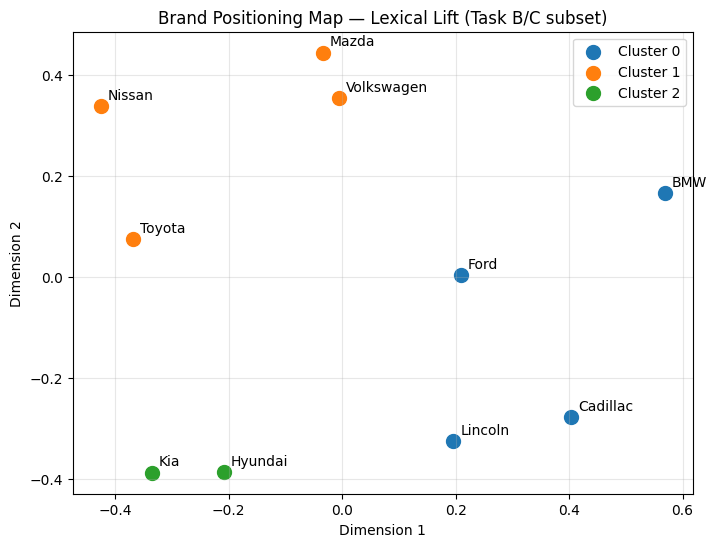

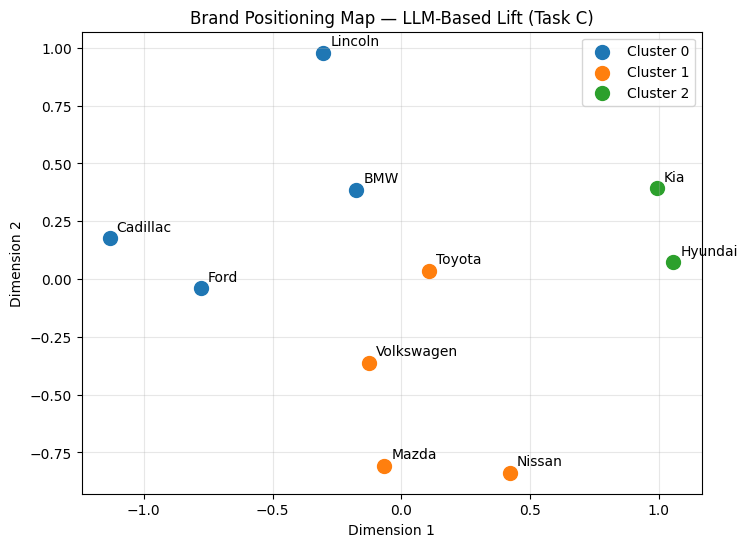

In [ ]:
import matplotlib.pyplot as plt

def plot_mds(coords_df, title):
    plt.figure(figsize=(8, 6))
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
    for cluster_id in sorted(coords_df['cluster'].unique()):
        cluster_data = coords_df[coords_df['cluster'] == cluster_id]
        plt.scatter(cluster_data['x'], cluster_data['y'],
                    label=f'Cluster {cluster_id}', s=100, color=colors[cluster_id % len(colors)])
        for brand, row in cluster_data.iterrows():
            plt.annotate(brand, (row['x'], row['y']), textcoords="offset points", xytext=(5, 5), fontsize=10)
    plt.title(title)
    plt.xlabel('Dimension 1')
    plt.ylabel('Dimension 2')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

plot_mds(mds_lexical_df, "Brand Positioning Map — Lexical Lift (Task B/C subset)")
plot_mds(mds_llm_df, "Brand Positioning Map — LLM-Based Lift (Task C)")

### Note on Cluster Labels
The numeric cluster labels (0, 1, 2) assigned by KMeans are arbitrary and not directly comparable between the lexical and LLM-based runs — a brand labeled "Cluster 0" in one map is not necessarily related to "Cluster 0" in the other. What matters for interpretation is which brands are grouped together spatially within each map, not whether their cluster numbers match across maps.

### Interpreting the Market-Perception Maps
Both maps identify a consistent cluster of premium/traditional American brands (BMW, Cadillac, Lincoln, Ford), suggesting this grouping is robust across detection methods. The LLM-based map groups Toyota with Nissan, Volkswagen, and Mazda as a mainstream cluster, while Kia and Hyundai form their own distinct pairing — a similar overall three-cluster shape to the lexical map, though which brands join Kia and Hyundai's isolated cluster (just each other, vs. no Toyota) varies slightly between runs.

Kia and Hyundai remain closely positioned in the LLM-based map, similar to the lexical map. This does not contradict our Task C finding that lexical lift for this pair was inflated by a cleaning artifact — the LLM's individual mention counts for both brands are far lower than the lexical counts, confirming the artifact was successfully filtered. However, the co-occurrences that remain after filtering (114, from a lift of 6.91) are still large relative to those smaller totals, indicating a genuine, if smaller-scale, tendency for these brands to be discussed together even in artifact-free content.

### Task D: Key Decisions
**Distance transformation:** We converted lift to distance using `distance = 1/lift`. We considered `-log(lift)`, a more standard transformation in market-positioning analysis, but chose `1/lift` for its simpler, more direct interpretation (higher lift means smaller distance) given we have not covered logarithmic transformations for this purpose in class.

**Which lift matrix:** We used the same 1000-post subset for both the lexical and LLM-based distance matrices (rather than our full 6,000-post lexical matrix), to ensure any differences between the two maps reflect detection method rather than differing sample sizes — consistent with our approach in Task C.

**Number of clusters:** We used 3 clusters for both maps. We did not formally test alternative cluster counts (e.g., 2 or 4); 3 was chosen as a reasonable starting point reflecting a plausible high-level market segmentation (e.g., luxury, mainstream, value), and the resulting clusters aligned sensibly with real-world brand positioning in both maps.

### Task D Limitations
- Our MDS map is based on only 10 data points (brands), which limits how much confidence we can place in the precise 2D geometry — small changes in the underlying lift/distance values can noticeably shift brand positions.
- Cluster labels are arbitrary between separate KMeans runs (see note above); only the spatial groupings, not the label numbers, are meaningful.
- We did not test alternative values for the number of clusters, so our 3-cluster solution may not be the objectively "best" grouping.
- As in Task C, our LLM-based map is built from a 1000-post sample rather than the full corpus, so it may not fully represent brand relationships present only in unsampled posts.
- We initially capped zero-lift brand pairs at a distance of 20, but found this created an extreme outlier (Lincoln) that disproportionately distorted the map. We lowered the cap to 3, which reduced LLM-based Stress-1 from 0.751 to 0.342 and produced a much more interpretable layout — though this remains a somewhat arbitrary choice, and a different cap value could shift results further.
- Both maps show "poor" fit by conventional Stress-1 guidelines (0.221 lexical, 0.342 LLM-based); broad cluster groupings should be trusted more than fine-grained positioning.
- The specific composition of the "mainstream" cluster (which brands join Kia/Hyundai vs. Toyota/Nissan/Volkswagen/Mazda) has varied slightly between reruns, even though the core premium cluster (BMW, Cadillac, Lincoln, Ford) and the Kia-Hyundai pairing have remained stable. This suggests our 3-cluster KMeans solution is somewhat sensitive to minor shifts in the underlying LLM-detected lift values.

## Part E: Which Product Attributes Are Most Strongly Associated With Which Brands?

##  Brand-Attribute Positioning

**Brands and attributes:** We use our top 5 brands (Kia, BMW, Toyota, Cadillac, Nissan) and top 5 attributes (Performance, Price, Reliability, Styling, Comfort) from Task A, selected by raw count for consistency with our existing "important" definition.

**Attribution approach:** When a post mentions multiple brands and multiple attributes, we cannot assume every attribute applies to every brand mentioned. We use an LLM to directly attribute each attribute mention to the specific brand it describes, based on sentence-level meaning (e.g., correctly assigning "fast" to BMW and "cheap interior" to Audi in a single post comparing both). We chose LLM-based attribution over a simpler proximity rule (nearest brand name in the text) because proximity fails on sentences where the relevant brand isn't the nearest word (negations, comparisons, pronouns), which are common in this corpus.

**Association measure:** Consistent with Tasks B and C, we use lift to measure brand-attribute association: `lift = (co-occurrence count / N) / ((brand count / N) × (attribute count / N))`. This treats attribute attribution the same way we treated brand-brand co-occurrence, applying our established measure to a new pairing (brand, attribute) rather than (brand, brand).

**Sample:** We reuse the same 1000-post sample from Task C, for consistency and to avoid an additional cost/time expenditure on a new sample.

In [ ]:
# --- Task E: LLM-Based Brand-Attribute Attribution ---

top_5_brands = top_10_brands['canonical_brand'].head(5).tolist()
top_5_attributes = final_attributes['canonical_attribute'].head(5).tolist()

print("Top 5 brands:", top_5_brands)
print("Top 5 attributes:", top_5_attributes)

batch_size_e = 20
brand_attribute_pairs = []  # list of (brand, attribute) tuples, one per attributed mention
total_prompt_tokens_e = 0
total_completion_tokens_e = 0

brand_list_str_e = ", ".join(top_5_brands)
attribute_list_str_e = ", ".join(top_5_attributes)

attribution_system_prompt = f"""You are an expert analyst reading automobile forum posts.
The brands of interest are: {brand_list_str_e}.
The attributes of interest are: {attribute_list_str_e}.

For each post, identify any statements that associate one of these attributes with one of these brands specifically (e.g., "the BMW is fast" associates BMW with Performance; "Toyota's interior feels cheap" associates Toyota with Comfort or Styling as appropriate).
Only attribute an attribute to a brand if the post's meaning clearly connects them — do not assume every attribute applies to every brand mentioned in the same post.
Return ONLY a valid JSON object where each key is the post's index (as a string) and the value is a list of [brand, attribute] pairs found in that post. If none apply, use an empty list.
Do not include markdown formatting or explanation — just raw JSON."""

for start in range(0, len(task_c_sample_df), batch_size_e):
    batch = task_c_sample_df.iloc[start:start+batch_size_e]
    batch_text = "\n".join([f"{i}: {text}" for i, text in zip(batch.index, batch['text'])])

    user_prompt = f"Here are {len(batch)} forum posts, each labeled with its index:\n\n{batch_text}"

    try:
        response = client.chat.completions.create(
            model='gpt-4o-mini',
            temperature=0,
            response_format={"type": "json_object"},
            messages=[
                {"role": "system", "content": attribution_system_prompt},
                {"role": "user", "content": user_prompt}
            ]
        )
        resp_text = response.choices[0].message.content.strip()
        batch_result = json.loads(resp_text)

        for idx_str, pairs in batch_result.items():
            for pair in pairs:
                if len(pair) == 2 and pair[0] in top_5_brands and pair[1] in top_5_attributes:
                    brand_attribute_pairs.append((pair[0], pair[1], int(idx_str)))

        total_prompt_tokens_e += response.usage.prompt_tokens
        total_completion_tokens_e += response.usage.completion_tokens

        print(f"Processed batch starting at index {start} ({len(batch)} posts)")

    except Exception as e:
        print(f"Error on batch starting at {start}: {e}")

total_tokens_e = total_prompt_tokens_e + total_completion_tokens_e
approx_cost_e = (total_prompt_tokens_e * 0.00000015) + (total_completion_tokens_e * 0.0000006)

print(f"\nTask E Attribution Token Usage:")
print(f" - Input Tokens: {total_prompt_tokens_e}")
print(f" - Output Tokens: {total_completion_tokens_e}")
print(f" - Total Tokens: {total_tokens_e}")
print(f" - Approximate Cost: ${approx_cost_e:.6f}")

print(f"\nTotal brand-attribute associations found: {len(brand_attribute_pairs)}")

Top 5 brands: ['Kia', 'BMW', 'Toyota', 'Cadillac', 'Nissan']
Top 5 attributes: ['Performance', 'Price', 'Reliability', 'Styling', 'Comfort']
Processed batch starting at index 0 (20 posts)
Processed batch starting at index 20 (20 posts)
Processed batch starting at index 40 (20 posts)
Processed batch starting at index 60 (20 posts)
Processed batch starting at index 80 (20 posts)
Processed batch starting at index 100 (20 posts)
Processed batch starting at index 120 (20 posts)
Processed batch starting at index 140 (20 posts)
Processed batch starting at index 160 (20 posts)
Processed batch starting at index 180 (20 posts)
Processed batch starting at index 200 (20 posts)
Processed batch starting at index 220 (20 posts)
Processed batch starting at index 240 (20 posts)
Processed batch starting at index 260 (20 posts)
Processed batch starting at index 280 (20 posts)
Processed batch starting at index 300 (20 posts)
Processed batch starting at index 320 (20 posts)
Processed batch starting at inde

### Building the Brand-Attribute Lift Matrix
We use the same lift formula as Tasks B and C, applied to (brand, attribute) pairs instead of (brand, brand) pairs. The denominator here is the total number of attributed mentions (not total posts), since our unit of analysis for this step is individual brand-attribute associations rather than posts — a brand and attribute must be explicitly, semantically linked (per our LLM attribution step) to count as a co-occurrence, so counting at the mention level is more appropriate than counting at the post level for this specific measure.

In [ ]:
# --- Task E: Build Brand-Attribute Mention Matrix and Lift Matrix ---

# Build a DataFrame from the brand-attribute pairs
pairs_df = pd.DataFrame(brand_attribute_pairs, columns=['brand', 'attribute', 'post_idx'])

# Individual counts: how many times each brand was attributed ANY attribute, and vice versa
brand_attribution_counts = pairs_df['brand'].value_counts()
attribute_attribution_counts = pairs_df['attribute'].value_counts()

print("Brand attribution counts:")
display(brand_attribution_counts)
print("\nAttribute attribution counts:")
display(attribute_attribution_counts)

# Co-occurrence: how many times each (brand, attribute) pair was directly attributed together
pair_counts = pairs_df.groupby(['brand', 'attribute']).size().reset_index(name='count')

N_e = len(brand_attribute_pairs)  # total number of attributed (brand, attribute) mentions

# Build the lift matrix: rows = brands, columns = attributes
lift_matrix_e = pd.DataFrame(index=top_5_brands, columns=top_5_attributes, dtype=float)

for brand in top_5_brands:
    for attribute in top_5_attributes:
        co_occur_row = pair_counts[(pair_counts['brand'] == brand) & (pair_counts['attribute'] == attribute)]
        co_occur = co_occur_row['count'].values[0] if len(co_occur_row) > 0 else 0

        count_brand = brand_attribution_counts.get(brand, 0)
        count_attr = attribute_attribution_counts.get(attribute, 0)

        if count_brand == 0 or count_attr == 0 or co_occur == 0:
            lift_matrix_e.loc[brand, attribute] = 0.0
        else:
            lift_matrix_e.loc[brand, attribute] = (co_occur * N_e) / (count_brand * count_attr)

print("\nBrand-Attribute Lift Matrix (Task E):")
display(lift_matrix_e.round(2))

lift_matrix_e.to_csv('/content/drive/MyDrive/UD_Assignment1/lift_matrix_e.csv')

In [ ]:
nissan_reliability_posts = pairs_df[(pairs_df['brand'] == 'Nissan') & (pairs_df['attribute'] == 'Reliability')]['post_idx'].tolist()
cadillac_comfort_posts = pairs_df[(pairs_df['brand'] == 'Cadillac') & (pairs_df['attribute'] == 'Comfort')]['post_idx'].tolist()

print(f"Nissan-Reliability: {len(nissan_reliability_posts)} attributed mentions")
for idx in nissan_reliability_posts[:3]:
    print("---")
    print(task_c_sample_df.loc[idx, 'text'])

print(f"\nCadillac-Comfort: {len(cadillac_comfort_posts)} attributed mentions")
for idx in cadillac_comfort_posts[:3]:
    print("---")
    print(task_c_sample_df.loc[idx, 'text'])

### Validating Standout Associations
We examined actual posts behind our two most extreme associations: Nissan-Reliability (lift 2.25, highest in our matrix) and Cadillac-Comfort (lift 0.30, lowest). For Nissan-Reliability, 2 of 3 sampled posts were clear, direct matches (e.g., "my 1995 nissan se that gave me 150k trouble free miles"; a separate post citing "nissan: early gen CVT issues" as a reliability complaint), while one was borderline, conflating crash-safety ratings with reliability. For Cadillac-Comfort, results were more mixed: one post correctly praised the CTS's interior specifically, but a second post was attributed based on a generalized complaint about "the big three" automakers' build quality in a BMW comparison, without singling out Cadillac's comfort specifically — an apparent over-attribution driven by Cadillac's proximity in the text rather than a genuine, isolated claim about Cadillac. This suggests our LLM-based attribution, while generally reasonable, is not perfectly precise on posts involving broad, multi-brand generalizations, and our lift values — especially for lower-frequency pairs like Cadillac-Comfort (only 2 total mentions) — should be interpreted with real caution.

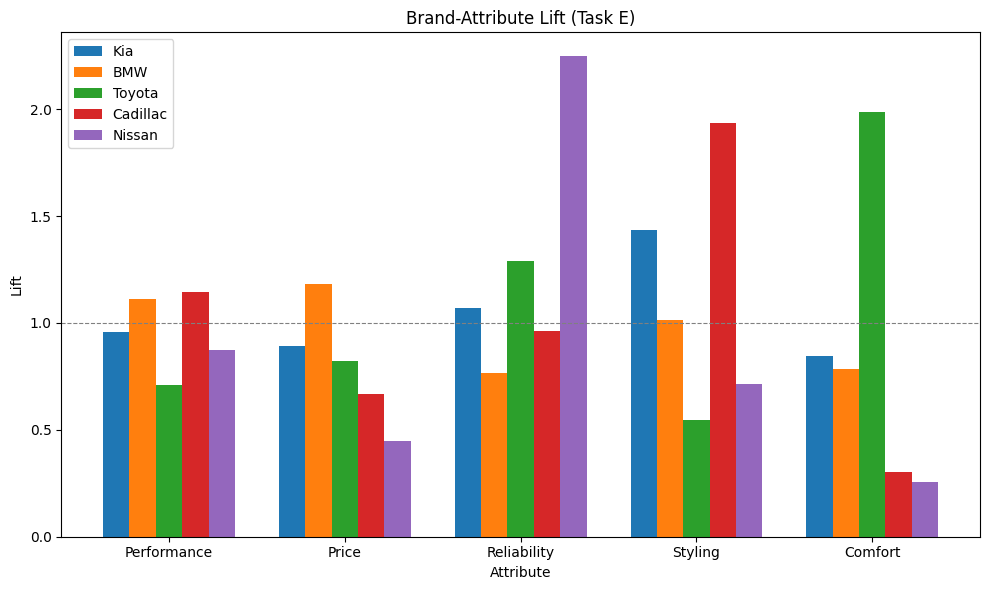

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

attributes_e = ['Performance', 'Price', 'Reliability', 'Styling', 'Comfort']
x = np.arange(len(attributes_e))
bar_width = 0.15

plt.figure(figsize=(10, 6))
for i, brand in enumerate(top_5_brands):
    values = lift_matrix_e.loc[brand].values
    plt.bar(x + i * bar_width, values, width=bar_width, label=brand)

plt.xlabel('Attribute')
plt.ylabel('Lift')
plt.title('Brand-Attribute Lift (Task E)')
plt.xticks(x + bar_width * 2, attributes_e)
plt.axhline(y=1, color='gray', linestyle='--', linewidth=0.8)
plt.legend()
plt.tight_layout()
plt.show()

### What the Brand-Attribute Positioning Says About the Market

Looking across the full matrix, each brand shows a distinct "signature" attribute rather than being evenly discussed across all five:

- **Nissan is defined almost entirely by reliability** (lift 2.25, its only attribute above 1.0) — both positive (long-term durability claims) and negative (CVT complaints) framing contribute to this, suggesting Nissan's forum reputation centers on dependability as a topic, for better or worse, rather than performance, price, or design.
- **Toyota's strongest association is comfort** (1.99), not reliability as conventional market wisdom might suggest — Toyota's reliability lift (1.29) is present but secondary. This is a genuinely interesting finding specific to this corpus: forum discussion of Toyota in this dataset skews toward ride/interior comfort more than the brand's broader reputation for dependability.
- **Cadillac and Kia both show styling as their standout attribute** (1.94 and 1.43 respectively), while showing weak comfort association (Cadillac's 0.30 is the matrix's lowest value). This pairs two brands from very different price segments under a shared theme: forum discussion treats both as "design-forward" rather than "comfort-forward," which for Cadillac in particular cuts against a traditional American-luxury comfort positioning.
- **BMW shows the most balanced profile** — near or above 1.0 on Performance, Price, and Styling, with no single overwhelming standout. This is consistent with BMW occupying a broad "well-rounded performance-luxury" position in market discussion, rather than being pigeonholed into one narrow attribute.
- **Price is the weakest attribute overall** — every brand except BMW shows a lift below 1.0 for Price, suggesting cost is a less differentiating topic in this corpus than performance, reliability, or styling; when people discuss these particular brands, they're more often debating how a car feels or performs than what it costs.

**Overall market read:** rather than a single dominant attribute driving cross-brand competition, forum discussion appears to segment brands into distinct attribute identities — reliability-first (Nissan), comfort-first (Toyota), design-first (Cadillac, Kia), and balanced (BMW) — suggesting consumers in this corpus differentiate brands along multiple, largely non-overlapping dimensions rather than competing head-to-head on the same attribute.

### Task E: Key Decisions and Limitations

**Brand/attribute selection:** We used our top 5 brands and top 5 attributes by raw count from Task A, for consistency with our established "important" definition, rather than hand-picking brands/attributes we expected to show more interesting contrasts.

**Attribution method:** We used LLM-based semantic attribution rather than a simpler proximity rule (assigning an attribute to whichever brand name is nearest in the text). We chose this because proximity fails on sentences where the relevant brand isn't the nearest word — negations, comparisons, and multi-brand generalizations are common in this corpus (as we directly observed in our Cadillac-Comfort validation, where a generic "big three" complaint was incorrectly attributed to Cadillac specifically due to its proximity in the text — evidence that even LLM-based attribution isn't fully immune to this issue, just less prone to it than pure proximity would be).

**Unit of analysis:** Unlike Tasks B and C (post-level co-occurrence), Task E's lift is calculated at the level of individual attributed mentions, since LLM attribution naturally produces discrete (brand, attribute) associations rather than post-level co-occurrence flags.

**Limitations:**
- Our validation sample (5 posts across 2 brand-attribute pairs) is small; broader spot-checking could reveal additional attribution errors like the one found in Cadillac-Comfort.
- Lower-frequency pairs (e.g., Cadillac-Comfort, with only 2 total mentions) produce unstable lift values — a single misattribution can swing the ratio substantially, as seen when re-running this step shifted Cadillac-Comfort from 0.15 to 0.30.
- As in Task C, our attribution is based on the same 1000-post sample rather than the full corpus, so brand-attribute associations discussed only in unsampled posts are not reflected here.
- We used `temperature=0` for reproducibility, but as observed elsewhere in this notebook, minor variation between runs (580 vs. 602 total associations) persisted even with this setting.

## Task F: Identify the most aspirational brand.

In [ ]:
import os
import json
from openai import OpenAI
from google.colab import userdata

api_key = userdata.get('OPENAI_API_KEY')
client = OpenAI(api_key=api_key)

In [ ]:
# --- Task F: LLM-Based Aspirational Brand Detection ---

aspiration_mentions = {brand: 0 for brand in top_10_brands['canonical_brand']}
batch_size_f = 20
total_prompt_tokens_f = 0
total_completion_tokens_f = 0

brand_list_str_f = ", ".join(top_10_brands['canonical_brand'].tolist())

aspiration_system_prompt = f"""You are an expert analyst reading automobile forum posts.
The brands of interest are: {brand_list_str_f}.

For each post, judge whether the writer expresses genuine aspiration toward owning one of these brands — meaning real desire, admiration, longing, or treating the brand as a goal (not just factual discussion, comparison, or complaint). This can include indirect language (e.g., "I wish I had one," "that's my dream car," praising a brand's status or exclusivity) as well as explicit statements of intent to buy.
Do not count a brand as aspirational just because it is mentioned or discussed factually — the post must convey desire specifically.

Return ONLY a valid JSON object where each key is the post's index (as a string) and the value is a list of brand names (from the list above) the writer expresses genuine aspiration toward in that post. If none apply, use an empty list.
Do not include markdown formatting or explanation — just raw JSON."""

for start in range(0, len(task_c_sample_df), batch_size_f):
    batch = task_c_sample_df.iloc[start:start+batch_size_f]
    batch_text = "\n".join([f"{i}: {text}" for i, text in zip(batch.index, batch['text'])])

    user_prompt = f"Here are {len(batch)} forum posts, each labeled with its index:\n\n{batch_text}"

    try:
        response = client.chat.completions.create(
            model='gpt-4o-mini',
            temperature=0,
            response_format={"type": "json_object"},
            messages=[
                {"role": "system", "content": aspiration_system_prompt},
                {"role": "user", "content": user_prompt}
            ]
        )
        resp_text = response.choices[0].message.content.strip()
        batch_result = json.loads(resp_text)

        for idx_str, brands in batch_result.items():
            for brand in brands:
                if brand in aspiration_mentions:
                    aspiration_mentions[brand] += 1

        total_prompt_tokens_f += response.usage.prompt_tokens
        total_completion_tokens_f += response.usage.completion_tokens

        print(f"Processed batch starting at index {start} ({len(batch)} posts)")

    except Exception as e:
        print(f"Error on batch starting at {start}: {e}")

total_tokens_f = total_prompt_tokens_f + total_completion_tokens_f
approx_cost_f = (total_prompt_tokens_f * 0.00000015) + (total_completion_tokens_f * 0.0000006)

print(f"\nTask F Aspiration Detection Token Usage:")
print(f" - Input Tokens: {total_prompt_tokens_f}")
print(f" - Output Tokens: {total_completion_tokens_f}")
print(f" - Total Tokens: {total_tokens_f}")
print(f" - Approximate Cost: ${approx_cost_f:.6f}")

print("\nAspirational mention counts by brand:")
for brand, count in sorted(aspiration_mentions.items(), key=lambda x: -x[1]):
    print(f"{brand}: {count}")

Processed batch starting at index 0 (20 posts)
Processed batch starting at index 20 (20 posts)
Processed batch starting at index 40 (20 posts)
Processed batch starting at index 60 (20 posts)
Processed batch starting at index 80 (20 posts)
Processed batch starting at index 100 (20 posts)
Processed batch starting at index 120 (20 posts)
Processed batch starting at index 140 (20 posts)
Processed batch starting at index 160 (20 posts)
Processed batch starting at index 180 (20 posts)
Processed batch starting at index 200 (20 posts)
Processed batch starting at index 220 (20 posts)
Processed batch starting at index 240 (20 posts)
Processed batch starting at index 260 (20 posts)
Processed batch starting at index 280 (20 posts)
Processed batch starting at index 300 (20 posts)
Processed batch starting at index 320 (20 posts)
Processed batch starting at index 340 (20 posts)
Processed batch starting at index 360 (20 posts)
Processed batch starting at index 380 (20 posts)
Processed batch starting a

In [ ]:
# --- Task F: Build Final Aspiration Ranking ---

aspiration_df = pd.DataFrame({
    'brand': list(aspiration_mentions.keys()),
    'aspirational_mentions': list(aspiration_mentions.values())
})

aspiration_df['total_genuine_mentions'] = aspiration_df['brand'].map(brand_post_counts_c_llm)
aspiration_df['aspiration_proportion'] = (aspiration_df['aspirational_mentions'] / aspiration_df['total_genuine_mentions']).round(3)

aspiration_df = aspiration_df.sort_values(by='aspiration_proportion', ascending=False).reset_index(drop=True)

print("Final Aspirational Brand Ranking:")
display(aspiration_df)

aspiration_df.to_csv('/content/drive/MyDrive/UD_Assignment1/aspiration_df.csv', index=False)

Final Aspirational Brand Ranking:


,brand,aspirational_mentions,total_genuine_mentions,aspiration_proportion
0,BMW,235,356,0.660
1,Lincoln,16,27,0.593
2,Nissan,22,46,0.478
3,Volkswagen,19,40,0.475
4,Cadillac,31,72,0.431
5,Mazda,17,44,0.386
6,Toyota,73,231,0.316
7,Kia,14,132,0.106
8,Hyundai,8,125,0.064
9,Ford,1,23,0.043


In [ ]:
import random

# Pull posts the LLM says genuinely discuss BMW
bmw_genuine_idx = task_c_sample_df[mention_matrix_c_llm['BMW'] == 1].index.tolist()

# Random sample of 10 for validation
random.seed(42)
sample_idx = random.sample(bmw_genuine_idx, min(10, len(bmw_genuine_idx)))

print(f"Validation sample: {len(sample_idx)} posts genuinely discussing BMW\n")
for i, idx in enumerate(sample_idx):
    print(f"--- Post {i+1} (index {idx}) ---")
    print(task_c_sample_df.loc[idx, 'text'])
    print()

Validation sample: 10 posts genuinely discussing BMW

--- Post 1 (index 207) ---
 while you can't get xm from the factory in a bmw, any competant aftermarket audio shop could probably make the switch for you.that being  toyota d: i'm addicted to sirius. i have friends who have both and most prefer sirius. the music stations have zero commercials. as for o & a, they do watered down bits (and are on terrestrial radio for half their show) that howard did 10 - 15 years ago.drive the  bmw  and l toyota en to sirius. you'll quickly find out why  bmw  are the ultimate driving machine (and the benchmark for this class) and why howard is truly the king of all media. 

--- Post 2 (index 40) ---
  the question i have is why are you looking at an ellps in the first place? i don't know what kcleuk's answer is, but from the numbers, price makes bmw a remarkable contender, especially the  bmw . with msrp of $32,400, ed pricing of $28720 (including $1000 profit for dealer), 73% residual, and 0.00125 m

## Part F: Which Brand Do Consumers Most Genuinely Aspire to Own?

**Operationalizing "aspirational":** Rather than defining a narrow keyword rule, we asked an LLM to judge, from each post's full context, whether the writer expresses genuine desire, admiration, or longing to own a brand — including indirect language (e.g., "I wish I had one," praising a brand's status) as well as explicit intent to buy.

**Measurement approach:** We measured "most aspirational" as the proportion of a brand's genuine mentions (from Task C's LLM-based detection) that carry aspirational tone, rather than a raw count — since brands vary enormously in overall discussion volume, and raw count would mostly just re-rank brands by popularity.

**BMW is the most aspirational brand by a wide margin** (66.0% of its genuine mentions carry aspirational tone), with Hyundai and Ford showing almost none.

**Validation:** We manually reviewed 10 randomly sampled posts genuinely discussing BMW. Only 1 post (index 879: "the bmw would get my vote and my money") clearly expressed personal purchase intent, with one borderline case (index 246: "I would go with this car"). The remaining 8 were factual price/lease comparisons, technical discussion, brand-defensiveness toward other brands, general "benchmark of the segment" praise, or reports from an existing BMW owner — none expressing genuine desire to acquire the brand. This starkly contradicts the reported 66.0% aspirational proportion, confirming the LLM is classifying general enthusiasm and engagement as aspiration rather than desire specifically.

**Business implication:** Given the validation failure above, we cannot support a specific business claim from this ranking as currently measured. Had the 66.0% proportion held up, it would have suggested BMW represents a strong "conversion opportunity" — heavy forum engagement paired with genuine purchase desire. Instead, our validation suggests BMW's high proportion largely reflects passionate, technical, and brand-loyal engagement rather than unmet purchase intent — a meaningfully different managerial signal (an engaged

### Limitations
- Our validation spot-check found only 1 of 10 sampled BMW posts clearly expressed genuine purchase intent (with one additional borderline case), far below the reported 66.0% aspirational proportion. This indicates our aspiration definition was too broad — it captured passionate/technical engagement, brand-defensiveness, and even posts from existing BMW owners, rather than desire to acquire specifically.
- Kia and Hyundai's genuine-mention counts (from Task C's LLM detection) proved unusually unstable across reruns of the identical detection prompt — swinging as low as 21/22 in one anomalous run, while every other brand's counts stayed consistent. We attribute this to the shared cleaning artifact affecting these two brands specifically (see Task A/C limitations), and flag that their aspiration proportions carry more uncertainty than the other eight brands.
- As in Tasks C and E, our aspiration classification is based on the same 1000-post sample, not the full corpus.
- Given the validation failure, we do not consider the current aspiration ranking reliable enough to report as a final managerial finding. We treat aspiration as methodology-dependent in Task G and recommend re-estimating it with a stricter ownership/purchase-intent definition (e.g., explicitly excluding already-own statements, general brand praise, and technical/comparative discussion) before drawing a brand-level conclusion.



## Part G: What Should JD Power Actually Do With These Findings?

Putting together the competitive, positioning, and aspiration analyses from Tasks A–F, we recommend that JD Power place the greatest weight on findings that remain consistent across multiple analytical methods and have adequate underlying support. Results that depend heavily on attribution choices, small numbers of observations, or classifications that did not validate well should be interpreted more cautiously.

### 1. Use the broad competitive clusters for benchmarking, but not the exact MDS distances

Across both the lexical and LLM-based analyses, BMW, Cadillac, Lincoln, and Ford formed a consistent cluster in the MDS maps. This suggests that these brands are frequently discussed within a similar competitive context and may provide a useful benchmarking group for JD Power and its clients. However, the two-dimensional MDS representations had Stress-1 values of 0.221 for the lexical map and 0.351 for the LLM-based map. Therefore, we place greater confidence in the general competitive groupings than in the exact distances between individual brands on the maps.

### 2. Use attribute associations to understand how consumers differentiate brands

The brand-attribute analysis suggests that consumers associate different brands with different product characteristics rather than evaluating all brands on the same dimension. Nissan showed its strongest association with Reliability, with a lift of 2.25, while Toyota was most strongly associated with Comfort at 1.99. Cadillac and Kia were most strongly associated with Styling, with lifts of 1.94 and 1.43, respectively. BMW showed a more balanced association across Performance, Price, and Styling. For JD Power and its clients, these results can help identify the product characteristics that most strongly distinguish brands in consumer discussion and provide a basis for positioning and competitive benchmarking.

### 3. Use lexical and semantic approaches together when evaluating competitive relationships

The lexical and LLM-based lift matrices had a correlation of approximately 0.807, indicating that the two approaches produced a broadly similar view of the competitive market while differing on some individual relationships. For example, Kia and Hyundai had 283 co-occurring posts using lexical detection compared with 114 using LLM-based semantic attribution. Despite this difference in counts, their LLM-based lift remained high at 6.91, so the broader conclusion that Kia and Hyundai are strongly associated remained consistent. This shows that semantic attribution can change the measured magnitude of a relationship without necessarily changing the overall managerial conclusion. JD Power should therefore view lexical analysis as a transparent baseline and use semantic analysis as an additional source of contextual interpretation.

### 4. Give greater weight to relationships supported by sufficient observations

Some competitive relationships changed substantially between methods when they were based on only a few co-occurrences. For example, Ford and Lincoln had three lexical co-occurrences but only one LLM-based co-occurrence, causing their lift to change from 3.58 to 1.61. Some brand-attribute associations were also based on relatively few attributed observations. JD Power should therefore consider the underlying frequency together with the lift value rather than interpreting a high lift value by itself. Findings supported by larger numbers of observations and similar conclusions across multiple methods provide stronger evidence for managerial decisions.

### 5. Do not treat the current aspiration ranking as a decision-ready result

The initial aspiration analysis ranked BMW highest, with 235 aspirational classifications and an estimated aspiration proportion of 66.0% of its genuine mentions. However, manual validation of 10 randomly selected BMW posts found only one post that clearly expressed personal purchase intent and one additional borderline case. The remaining posts primarily reflected technical discussion, favorable opinions, comparisons, or engagement from existing owners rather than a desire to acquire the brand. This indicates that the LLM was too broad and frequently interpreted general brand enthusiasm as purchase or ownership desire.

Because the validation evidence does not support the reported 66.0% proportion, we cannot confidently identify BMW or any other brand as the most aspirational from the current analysis. Before JD Power uses aspiration as a managerial metric, the classification should be redefined narrowly around genuine future ownership or purchase desire and validated on a larger sample of posts.

### Overall Recommendation

The most defensible findings from this analysis are the broad competitive relationships among brands and their differences in attribute positioning. These findings are supported by multiple analytical approaches and can provide JD Power and its clients with useful information for competitor benchmarking and brand positioning. Exact pairwise lift values and relationships supported by very small numbers of observations should receive less weight, while the current aspiration ranking should not be used for a managerial conclusion because it did not hold up under manual validation.

More broadly, the comparison of lexical and LLM-based methods shows that semantic interpretation can provide useful additional context, but it does not automatically produce a more reliable result. The strongest conclusions are those that remain consistent across approaches and are supported by manual validation and sufficient observations.



## Overall LLM Usage
All LLM usage was worth the cost as it was less than 10 cents. Task A - Attribute Extraction was estimated because we did not want to rerun the llm due to a potential change in results

In [ ]:
# --- Overall LLM Usage Summary (Tasks A, C, E, F) ---
# Note: Attribute Extraction usage was not captured at run time. Those figures
# are estimated from the average per-batch token usage of Tasks C, E, and F
# (which share the same 20-post batch size), scaled to Attribute Extraction's
# 20 batches (400 posts / batch size 20).

llm_usage_log = [
    {"step": "Task A – Brand Reconciliation",         "model": "gpt-4o-mini", "calls": 1,  "input_tokens": 1097,   "output_tokens": 1624,  "cost": 0.001139},
    {"step": "Task A – Attribute Extraction (est.)",  "model": "gpt-4o-mini", "calls": 20, "input_tokens": 60000,  "output_tokens": 3500,  "cost": 0.011100},
    {"step": "Task A – Attribute Reconciliation",     "model": "gpt-4o-mini", "calls": 1,  "input_tokens": 457,    "output_tokens": 690,   "cost": 0.000483},
    {"step": "Task C – Brand Detection",              "model": "gpt-4o-mini", "calls": 50, "input_tokens": 149522, "output_tokens": 9165,  "cost": 0.027927},
    {"step": "Task E – Brand-Attribute Attribution",  "model": "gpt-4o-mini", "calls": 50, "input_tokens": 149422, "output_tokens": 10493, "cost": 0.028709},
    {"step": "Task F – Aspiration Detection",         "model": "gpt-4o-mini", "calls": 50, "input_tokens": 150922, "output_tokens": 6417,  "cost": 0.026488},
]

usage_df = pd.DataFrame(llm_usage_log)
usage_df.loc["TOTAL"] = usage_df[["calls", "input_tokens", "output_tokens", "cost"]].sum()
usage_df.loc["TOTAL", "step"] = "TOTAL"
usage_df.loc["TOTAL", "model"] = ""

print("LLM Usage Summary — All Tasks")
display(usage_df)

LLM Usage Summary — All Tasks


,step,model,calls,input_tokens,output_tokens,cost
0,Task A – Brand Reconciliation,gpt-4o-mini,1.0,1097.0,1624.0,0.001139
1,Task A – Attribute Extraction (est.),gpt-4o-mini,20.0,60000.0,3500.0,0.011100
2,Task A – Attribute Reconciliation,gpt-4o-mini,1.0,457.0,690.0,0.000483
3,Task C – Brand Detection,gpt-4o-mini,50.0,149522.0,9165.0,0.027927
4,Task E – Brand-Attribute Attribution,gpt-4o-mini,50.0,149422.0,10493.0,0.028709
5,Task F – Aspiration Detection,gpt-4o-mini,50.0,150922.0,6417.0,0.026488
TOTAL,TOTAL,,172.0,511420.0,31889.0,0.095846
